# Singular FBSDE Deep BSDE experiments

## 1 Numerical setup

In [1]:
from __future__ import annotations

import copy
import json
import math
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

RESULTS_DIR = Path.cwd() / "dissertation_moving_boundary_final_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Device", DEVICE)
if DEVICE.type == "cuda":
    print("GPU", torch.cuda.get_device_name(0))
print("Results directory", RESULTS_DIR.resolve())
print("Random seed", SEED)

Device cuda
GPU NVIDIA A100-SXM4-40GB
Results directory /content/dissertation_moving_boundary_final_results
Random seed 123


### 1.1 Configuration

In [2]:
@dataclass(frozen=True)
class OptimConfig:
    iterations: int = 15_000
    batch_size: int = 1_024
    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    gradient_clip: float = 10.0
    validation_every: int = 200
    display_every: int = 200
    direct_seed: int = 123
    direct_antithetic: bool = True


@dataclass(frozen=True)
class CascadeConfig:
    terminal_time: float = 1.0
    sigma: float = 1.0
    alpha: float = 1.0

    x_min: float = 1.0
    x_max: float = 4.0
    singleton_x_min: float = 2.001
    max_start_time: float = 0.95

    train_steps: int = 40
    width: int = 64
    depth: int = 3
    validation_size: int = 8_192

    reference_grid_size: int = 61
    reference_paths: int = 2_048
    reference_steps: int = 400
    reference_point_batch: int = 32

    model_plot_grid_size: int = 181
    diagnostic_paths: int = 20_000
    diagnostic_steps: int = 400

    geometry_times: tuple[float, ...] = (
        0.00, 0.20, 0.40, 0.60, 0.75, 0.90, 0.95, 1.00
    )
    comparison_times: tuple[float, ...] = (
        0.00, 0.50, 0.90, 0.95
    )


OPTIM = OptimConfig()
CASCADE = CascadeConfig()

configuration = {
    "seed": SEED,
    "optim": asdict(OPTIM),
    "cascade": asdict(CASCADE),
    "device": str(DEVICE),
    "torch": torch.__version__,
    "numpy": np.__version__,
    "python": sys.version,
    "platform": platform.platform(),
}
with (RESULTS_DIR / "configuration.json").open("w", encoding="utf-8") as file:
    json.dump(configuration, file, indent=2, sort_keys=True)

display(pd.DataFrame({
    "setting": [
        "training iterations for every learned model",
        "batch size",
        "training time steps",
        "direct training uses antithetic pairs",
        "exact-boundary benchmark model seed",
        "direct model seed",
        "singleton model seed",
        "two-particle model seed",
        "reference time steps",
        "reference paths per point",
        "reference heatmap times",
    ],
    "value": [
        OPTIM.iterations,
        OPTIM.batch_size,
        CASCADE.train_steps,
        OPTIM.direct_antithetic,
        SEED + 200,
        OPTIM.direct_seed,
        SEED + 500,
        SEED + 600,
        CASCADE.reference_steps,
        CASCADE.reference_paths,
        len(CASCADE.geometry_times),
    ],
}))

,setting,value
0,training iterations for every learned model,15000
1,batch size,1024
2,training time steps,40
3,direct training uses antithetic pairs,True
4,exact-boundary benchmark model seed,323
5,direct model seed,123
6,singleton model seed,623
7,two-particle model seed,723
8,reference time steps,400
9,reference paths per point,2048


### 1.2 Randomness and utilities

In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int) -> torch.Generator:
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    return generator


def uniform(
    shape: tuple[int, ...],
    low: float,
    high: float,
    generator: torch.Generator,
) -> Tensor:
    return low + (high - low) * torch.rand(
        shape,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )


def tensor_to_numpy(value: Tensor) -> np.ndarray:
    return value.detach().cpu().numpy()


def normal_cdf(value: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(value / math.sqrt(2.0)))


def masked_mean(value: Tensor, mask: Tensor) -> Tensor:
    if bool(mask.any()):
        return value[mask].mean()
    return value.sum() * 0.0


def first_true_index(mask: Tensor) -> tuple[Tensor, Tensor]:
    if mask.ndim != 2:
        raise ValueError("mask must have shape (batch,time)")
    hit = mask.any(dim=1)
    index = mask.to(torch.int64).argmax(dim=1)
    final_index = mask.shape[1] - 1
    index = torch.where(hit, index, torch.full_like(index, final_index))
    return index, hit


def time_column(
    t: float | Tensor,
    batch_size: int,
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> Tensor:
    t_tensor = torch.as_tensor(t, device=device, dtype=dtype)
    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(batch_size)
    return t_tensor.reshape(batch_size, 1)


def save_figure(fig: plt.Figure, path: Path, *, show: bool = True) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

### 1.3 Neural architectures

In [4]:
class NormalisedMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        width: int,
        depth: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()
        if len(center) != input_dim or len(scale) != input_dim:
            raise ValueError("normalisation dimensions do not match input")

        self.register_buffer(
            "center",
            torch.tensor(center, dtype=DTYPE).reshape(1, -1),
        )
        self.register_buffer(
            "scale",
            torch.tensor(scale, dtype=DTYPE).reshape(1, -1),
        )

        layers: list[nn.Module] = []
        current = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(current, width))
            layers.append(nn.Softplus())
            current = width
        layers.append(nn.Linear(current, output_dim))
        self.network = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: Tensor) -> Tensor:
        normalised = (x - self.center) / self.scale
        return self.network(normalised)

    def zero_last_layer(self) -> None:
        final = next(
            module
            for module in reversed(self.network)
            if isinstance(module, nn.Linear)
        )
        nn.init.zeros_(final.weight)
        nn.init.zeros_(final.bias)


class BoundedSingletonFBSDE(nn.Module):
    # Stopped singleton approximation used by the proposed cascade.
    def __init__(
        self,
        *,
        x_min: float,
        x_max: float,
        width: int,
        depth: int,
    ) -> None:
        super().__init__()
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)
        center = (0.5, x_center)
        scale = (0.5, x_scale)

        self.value_net = NormalisedMLP(
            2, 1, width, depth, center, scale
        )
        self.z_net = NormalisedMLP(
            2, 1, width, depth, center, scale
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        x_flat = x.reshape(-1)
        t_col = time_column(
            t, x_flat.shape[0], device=x.device, dtype=x.dtype
        )
        raw = self.value_net(
            torch.cat((t_col, x_flat.unsqueeze(1)), dim=1)
        )[:, 0]
        return 1.0 + torch.sigmoid(raw)

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        x_flat = x.reshape(-1)
        t_col = time_column(
            t, x_flat.shape[0], device=x.device, dtype=x.dtype
        )
        return self.z_net(
            torch.cat((t_col, x_flat.unsqueeze(1)), dim=1)
        )[:, 0]


class SymmetricTwoParticleFBSDE(nn.Module):
    # Permutation-invariant scalar living-particle-count field.
    def __init__(
        self,
        *,
        x_min: float,
        x_max: float,
        width: int,
        depth: int,
    ) -> None:
        super().__init__()
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)

        self.value_net = NormalisedMLP(
            3,
            1,
            width,
            depth,
            center=(0.5, x_center, 0.5 * x_scale**2),
            scale=(0.5, x_scale, 0.5 * x_scale**2),
        )
        self.z_component_net = NormalisedMLP(
            3,
            1,
            width,
            depth,
            center=(0.5, x_center, x_center),
            scale=(0.5, x_scale, x_scale),
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        t_col = time_column(t, x.shape[0], device=x.device, dtype=x.dtype)
        mean = x.mean(dim=1, keepdim=True)
        half_gap_squared = 0.25 * (x[:, 0:1] - x[:, 1:2]).square()
        return self.value_net(
            torch.cat((t_col, mean, half_gap_squared), dim=1)
        )[:, 0]

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        t_col = time_column(t, x.shape[0], device=x.device, dtype=x.dtype)
        z1 = self.z_component_net(
            torch.cat((t_col, x[:, 0:1], x[:, 1:2]), dim=1)
        )
        z2 = self.z_component_net(
            torch.cat((t_col, x[:, 1:2], x[:, 0:1]), dim=1)
        )
        return torch.cat((z1, z2), dim=1)

class DirectGlobalFBSDE(nn.Module):
    """Direct vector-valued Deep BSDE approximation.
    V_theta takes (X_0, I_0) and returns the two initial backward values.
    W_theta takes (t_k, X_k, I_k) and returns the 2 x 2 martingale matrix.
    No range constraint, clipping, analytical boundary, or cascade information is imposed.
    """
    def __init__(
        self,
        *,
        x_min: float,
        x_max: float,
        width: int,
        depth: int,
    ) -> None:
        super().__init__()
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)

        self.value_net = NormalisedMLP(
            4,
            2,
            width,
            depth,
            center=(x_center, x_center, 0.5, 0.5),
            scale=(x_scale, x_scale, 0.5, 0.5),
        )
        self.z_net = NormalisedMLP(
            5,
            4,
            width,
            depth,
            center=(0.5, x_center, x_center, 0.5, 0.5),
            scale=(0.5, x_scale, x_scale, 0.5, 0.5),
        )

    def value(self, x: Tensor, alive: Tensor) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        if alive.shape != x.shape:
            raise ValueError("alive must have shape (batch,2)")
        features = torch.cat((x, alive), dim=1)
        return self.value_net(features)

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
        alive: Tensor,
    ) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        t_col = time_column(t, x.shape[0], device=x.device, dtype=x.dtype)
        features = torch.cat((t_col, x, alive), dim=1)
        return self.z_net(features).reshape(-1, 2, 2)

    def aggregate_value(self, x: Tensor) -> Tensor:
        alive = torch.ones_like(x)
        return self.value(x, alive).sum(dim=1)

### 1.4 Brownian simulation and Deep BSDE recursions

In [5]:
@dataclass
class BrownianBatch:
    start_time: Tensor
    times: Tensor
    x0: Tensor
    paths: Tensor
    increments: Tensor


def sample_brownian_batch(
    *,
    batch_size: int,
    dimension: int,
    steps: int,
    x_min: float,
    x_max: float,
    max_start_time: float,
    sigma: float,
    generator: torch.Generator,
    antithetic: bool,
) -> BrownianBatch:
    """Simulate Brownian paths from a possibly random start time.

    Every path uses exactly ``steps`` increments between its sampled start
    time rho and T, so its step size is (T-rho)/steps. With 40 training
    steps, a path starting at 0.95 therefore has step size 0.00125, whereas
    a path starting at 0 has step size 0.025.
    """
    if antithetic and batch_size % 2 != 0:
        raise ValueError("antithetic batch size must be even")

    base_size = batch_size // 2 if antithetic else batch_size
    start_time = uniform((base_size,), 0.0, max_start_time, generator)
    x0 = uniform((base_size, dimension), x_min, x_max, generator)
    normals = torch.randn(
        base_size,
        steps,
        dimension,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

    if antithetic:
        start_time = torch.cat((start_time, start_time.clone()), dim=0)
        x0 = torch.cat((x0, x0.clone()), dim=0)
        normals = torch.cat((normals, -normals), dim=0)

    dt = (CASCADE.terminal_time - start_time) / steps
    increments = sigma * torch.sqrt(dt).view(-1, 1, 1) * normals
    fraction = torch.arange(
        steps + 1, device=DEVICE, dtype=DTYPE
    ).view(1, -1) / steps
    times = (
        start_time[:, None]
        + (CASCADE.terminal_time - start_time)[:, None] * fraction
    )

    zero = torch.zeros(
        batch_size, 1, dimension, device=DEVICE, dtype=DTYPE
    )
    paths = x0[:, None, :] + torch.cat(
        (zero, increments.cumsum(dim=1)), dim=1
    )
    return BrownianBatch(start_time, times, x0, paths, increments)


def forward_singleton(
    model: BoundedSingletonFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(batch.start_time, batch.x0[:, 0])
    for k in range(batch.increments.shape[1]):
        not_stopped = (stop_index > k).to(DTYPE)
        z = model.z(batch.times[:, k], batch.paths[:, k, 0])
        y = y + not_stopped * z * batch.increments[:, k, 0]
    return y


def forward_two_particle(
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(batch.start_time, batch.x0)
    for k in range(batch.increments.shape[1]):
        not_stopped = (stop_index > k).to(DTYPE)
        z = model.z(batch.times[:, k], batch.paths[:, k])
        y = y + not_stopped * (z * batch.increments[:, k]).sum(dim=1)
    return y

def _apply_direct_killing_events(
    *,
    y: Tensor,
    x: Tensor,
    alive: Tensor,
    killed: Tensor,
    first_exit_index: Tensor,
    first_exit_hit: Tensor,
    grid_index: int,
) -> tuple[Tensor, Tensor, Tensor, Tensor]:
    """Detect killing events from the current raw Deep BSDE state.
    A killing event changes the set of living particles, but its current Y value is not overwritten.
    The terminal loss must therefore learn the value 1 on killed components rather
    than receiving that value for free.
    """
    # The stopping decision is a hard Boolean event.  Autograd therefore does not differentiate through how a parameter perturbation changes the hitting event or terminal label.  Gradients are taken only through the continuous rollout conditional on the currently selected event pattern.
    with torch.no_grad():
        threshold = CASCADE.alpha * y.sum(dim=1, keepdim=True)
        new_killing = alive & (x <= threshold)
        path_has_new_killing = new_killing.any(dim=1)
        first_event = (~first_exit_hit) & path_has_new_killing
        first_exit_index = torch.where(
            first_event,
            torch.full_like(first_exit_index, grid_index),
            first_exit_index,
        )
        first_exit_hit = first_exit_hit | path_has_new_killing
        killed = killed | new_killing
        alive = alive & (~new_killing)
    return alive, killed, first_exit_index, first_exit_hit


def direct_global_rollout(
    model: DirectGlobalFBSDE,
    batch: BrownianBatch,
    *,
    return_history: bool = False,
) -> dict[str, Tensor]:
    batch_size = batch.x0.shape[0]
    n_steps = batch.increments.shape[1]
    alive = torch.ones(
        batch_size, 2, device=DEVICE, dtype=torch.bool
    )
    killed = torch.zeros_like(alive)
    first_exit_index = torch.full(
        (batch_size,), n_steps, device=DEVICE, dtype=torch.long
    )
    first_exit_hit = torch.zeros(
        batch_size, device=DEVICE, dtype=torch.bool
    )

    # Alive-particle-mask initial condition Y_0 = V_theta(X_0, I_0).
    y = model.value(batch.x0, alive.to(DTYPE))

    y_history = [y.clone()] if return_history else []
    alive_history = [alive.clone()] if return_history else []

    for k in range(n_steps):
        current_x = batch.paths[:, k]
        current_t = batch.times[:, k]

        alive, killed, first_exit_index, first_exit_hit = (
            _apply_direct_killing_events(
                y=y,
                x=current_x,
                alive=alive,
                killed=killed,
                first_exit_index=first_exit_index,
                first_exit_hit=first_exit_hit,
                grid_index=k,
            )
        )

        z = model.z(current_t, current_x, alive.to(DTYPE))
        martingale_increment = torch.einsum(
            "bij,bj->bi", z, batch.increments[:, k]
        )
        y_candidate = y + martingale_increment

        # Once a component is killed, its diffusion is switched off.  Its value
        # is frozen at the learned hitting value; it is not hard-set to 1.
        y = torch.where(alive, y_candidate, y)

        if return_history:
            y_history.append(y.clone())
            alive_history.append(alive.clone())

    alive, killed, first_exit_index, first_exit_hit = (
        _apply_direct_killing_events(
            y=y,
            x=batch.paths[:, -1],
            alive=alive,
            killed=killed,
            first_exit_index=first_exit_index,
            first_exit_hit=first_exit_hit,
            grid_index=n_steps,
        )
    )

    target = killed.to(DTYPE)
    result = {
        "terminal_y": y,
        "target": target,
        "killed": killed,
        "alive": alive,
        "first_exit_index": first_exit_index,
        "first_exit_hit": first_exit_hit,
    }
    if return_history:
        result["y_history"] = torch.stack(y_history, dim=1)
        result["alive_history"] = torch.stack(alive_history, dim=1)
    return result


def direct_global_loss(
    model: DirectGlobalFBSDE,
    batch: BrownianBatch,
) -> Tensor:
    rollout = direct_global_rollout(model, batch)
    return (rollout["terminal_y"] - rollout["target"]).square().mean()


@torch.no_grad()
def direct_rollout_range_diagnostics(
    model: DirectGlobalFBSDE,
    batch: BrownianBatch,
) -> dict[str, float]:
    rollout = direct_global_rollout(model, batch, return_history=True)
    history = rollout["y_history"]
    living_history = rollout["alive_history"]
    living_values = history[living_history]

    if living_values.numel() == 0:
        return {
            "path_range_violation_rate": 0.0,
            "path_value_minimum": math.nan,
            "path_value_maximum": math.nan,
        }

    violation = (living_values < 0.0) | (living_values > 1.0)
    return {
        "path_range_violation_rate": float(
            violation.to(DTYPE).mean().cpu()
        ),
        "path_value_minimum": float(living_values.min().cpu()),
        "path_value_maximum": float(living_values.max().cpu()),
    }

### 1.5 Training and plotting utilities

In [6]:
@dataclass
class TrainingResult:
    best_iteration: int
    best_validation_loss: float
    runtime_seconds: float
    history: pd.DataFrame


def plot_training_history(
    result: TrainingResult,
    title: str,
    path: Path,
) -> None:
    if result.history.empty:
        return

    fig, ax = plt.subplots(figsize=(7.0, 4.3), constrained_layout=True)
    floor = np.finfo(float).tiny

    train = result.history.dropna(subset=["training_loss"])
    validation = result.history.dropna(subset=["validation_loss"])

    ax.semilogy(
        train["iteration"],
        np.maximum(train["training_loss"], floor),
        linewidth=0.9,
        label="training",
    )
    ax.semilogy(
        validation["iteration"],
        np.maximum(validation["validation_loss"], floor),
        marker="o",
        markersize=2.5,
        linewidth=0.9,
        label="validation",
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean squared objective")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    save_figure(fig, path, show=False)


def train(
    *,
    model: nn.Module,
    name: str,
    output_dir: Path,
    train_objective: Callable[[nn.Module], Tensor],
    validation_objective: Callable[[nn.Module], Tensor],
    iterations: int,
    learning_rate: float = 1.0e-3,
    validation_every: int = 200,
    display_every: int = 200,
    scheduler_step: int = 1_000,
    scheduler_gamma: float = 0.95,
    gradient_clip: float = 10.0,
) -> TrainingResult:
    output_dir.mkdir(parents=True, exist_ok=True)
    history_path = output_dir / f"{name}_history.csv"

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step,
        gamma=scheduler_gamma,
    )

    best_loss = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    records: list[dict[str, float]] = []
    start = time.time()

    for iteration in range(1, iterations + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        loss = train_objective(model)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"non-finite loss in {name}")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()
        scheduler.step()

        validation_value = math.nan
        if iteration % validation_every == 0 or iteration == iterations:
            model.eval()
            with torch.no_grad():
                validation_value = float(validation_objective(model).item())
            if validation_value < best_loss:
                best_loss = validation_value
                best_iteration = iteration
                best_state = copy.deepcopy(model.state_dict())

        if iteration % display_every == 0 or iteration == iterations:
            train_value = float(loss.item())
            records.append({
                "iteration": iteration,
                "training_loss": train_value,
                "validation_loss": validation_value,
            })
            print(
                f"{name:34s} iteration {iteration:5d} "
                f"train {train_value:.6e} val {validation_value:.6e}"
            )

    runtime = time.time() - start
    model.load_state_dict(best_state)

    history = pd.DataFrame(records)
    history.to_csv(history_path, index=False)

    return TrainingResult(
        best_iteration=best_iteration,
        best_validation_loss=best_loss,
        runtime_seconds=runtime,
        history=history,
    )

EXACT_BOUNDARY_STYLE = {
    "color": "red",
    "linestyle": (0, (10, 5)),
    "linewidth": 1.25,
    "alpha": 0.95,
}
LEARNED_BOUNDARY_STYLE = {
    "color": "cyan",
    "linestyle": "-",
    "linewidth": 1.05,
    "alpha": 0.95,
}


@torch.no_grad()
def feasible_graph_branch(
    time_value: float,
    boundary_function: Callable[[float, Tensor], Tensor],
    *,
    points: int = 800,
) -> tuple[Tensor, Tensor]:

    lower = max(CASCADE.x_min, 2.0 * CASCADE.alpha)
    remaining_coordinate = torch.linspace(
        lower,
        CASCADE.x_max,
        points,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = boundary_function(time_value, remaining_coordinate)
    feasible = boundary <= remaining_coordinate + 10.0 * torch.finfo(DTYPE).eps
    return remaining_coordinate[feasible], boundary[feasible]


def plot_exact_boundary(
    ax: plt.Axes,
    time_value: float,
    *,
    label: str | None = None,
    zorder: float = 5.0,
) -> None:
    for curve_index, (x_curve, y_curve) in enumerate(
        exact_boundary_curves(time_value)
    ):
        ax.plot(
            x_curve,
            y_curve,
            **EXACT_BOUNDARY_STYLE,
            zorder=zorder,
            label=label if curve_index == 0 else None,
        )


def plot_graph_boundary(
    ax: plt.Axes,
    time_value: float,
    boundary_function: Callable[[float, Tensor], Tensor],
    *,
    color: str = "cyan",
    linestyle: str | tuple = "-",
    linewidth: float = 1.05,
    label: str | None = None,
    zorder: float = 6.0,
) -> None:
    remaining_coordinate, boundary = feasible_graph_branch(
        time_value, boundary_function, points=800
    )
    ax.plot(
        tensor_to_numpy(boundary),
        tensor_to_numpy(remaining_coordinate),
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=zorder,
        label=label,
    )
    ax.plot(
        tensor_to_numpy(remaining_coordinate),
        tensor_to_numpy(boundary),
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=zorder,
    )


def plot_four_heatmaps(
    *,
    surfaces: dict[float, tuple[np.ndarray, np.ndarray]],
    title: str,
    output_path: Path,
    boundary_plotter: Callable[[plt.Axes, float], None],
    value_min: float = 0.0,
    value_max: float = 2.0,
) -> None:
    fig, axes = plt.subplots(
        2, 2, figsize=(10.8, 9.0), constrained_layout=True
    )
    image = None

    for ax, time_value in zip(axes.flat, CASCADE.comparison_times):
        axis, field = surfaces[float(time_value)]
        image = ax.imshow(
            field.T,
            origin="lower",
            extent=[axis[0], axis[-1], axis[0], axis[-1]],
            aspect="equal",
            interpolation="bilinear",
            cmap="viridis",
            vmin=value_min,
            vmax=value_max,
        )
        boundary_plotter(ax, float(time_value))
        ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
        ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
        ax.set_aspect("equal")
        ax.set_xlabel("x₁")
        ax.set_ylabel("x₂")
        ax.set_title(f"t = {time_value:.2f}")

    if image is None:
        raise RuntimeError("No heatmap was created.")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    if handles:
        axes.flat[0].legend(fontsize=8, loc="upper right")
    colorbar = fig.colorbar(image, ax=axes, shrink=0.84)
    colorbar.set_label("Value")
    fig.suptitle(title)
    save_figure(fig, output_path)

## 2 External Monte Carlo reference

In [7]:
def exact_singleton_value(
    t: float | Tensor,
    x: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    t_tensor = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_tensor, x_tensor = torch.broadcast_tensors(t_tensor, x)

    remaining = config.terminal_time - t_tensor
    terminal = torch.where(
        x_tensor <= 2.0 * config.alpha,
        torch.full_like(x_tensor, 2.0),
        torch.full_like(x_tensor, 1.0),
    )

    safe_remaining = remaining.clamp_min(torch.finfo(x.dtype).eps)
    argument = torch.minimum(
        (2.0 * config.alpha - x_tensor)
        / (config.sigma * torch.sqrt(safe_remaining)),
        torch.zeros_like(x_tensor),
    )
    preterminal = 1.0 + 2.0 * normal_cdf(argument)
    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )


def exact_boundary_value(
    t: float | Tensor,
    remaining_coordinate: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    return config.alpha * exact_singleton_value(t, remaining_coordinate, config)


def exact_terminal_domain_mask(
    points: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    return (
        (smaller > config.alpha)
        & (larger > 2.0 * config.alpha)
    )


def exact_domain_mask(
    t: float | Tensor,
    points: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    t_tensor = torch.as_tensor(
        t, device=points.device, dtype=points.dtype
    )
    if (
        t_tensor.ndim == 0
        and abs(float(t_tensor.item()) - config.terminal_time)
        <= 1.0e-12
    ):
        return exact_terminal_domain_mask(points, config)

    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(points.shape[0])

    return smaller > exact_boundary_value(t_tensor, larger, config)


def exact_boundary_curves(
    t: float,
    config: CascadeConfig = CASCADE,
) -> list[tuple[np.ndarray, np.ndarray]]:
    if abs(t - config.terminal_time) <= 1.0e-12:
        low = np.linspace(config.x_min, 2.0 * config.alpha, 500)
        high = np.linspace(2.0 * config.alpha, config.x_max, 500)
        return [
            (np.full_like(low, 2.0 * config.alpha), low),
            (low, np.full_like(low, 2.0 * config.alpha)),
            (np.full_like(high, config.alpha), high),
            (high, np.full_like(high, config.alpha)),
        ]

    remaining_coordinate = torch.linspace(
        max(config.x_min, 2.0 * config.alpha),
        config.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = exact_boundary_value(t, remaining_coordinate, config)
    feasible = boundary <= remaining_coordinate + 10.0 * torch.finfo(DTYPE).eps
    remaining_coordinate = remaining_coordinate[feasible]
    boundary = boundary[feasible]
    return [
        (tensor_to_numpy(boundary), tensor_to_numpy(remaining_coordinate)),
        (tensor_to_numpy(remaining_coordinate), tensor_to_numpy(boundary)),
    ]


r_left = torch.linspace(
    1.0, 2.0, 101, device=DEVICE, dtype=DTYPE
)
r_right = torch.linspace(
    2.001, 4.0, 201, device=DEVICE, dtype=DTYPE
)

for t_value in CASCADE.geometry_times:
    if t_value < 1.0:
        torch.testing.assert_close(
            exact_boundary_value(t_value, r_left),
            torch.full_like(r_left, 2.0),
            atol=2.0e-6,
            rtol=0.0,
        )

torch.testing.assert_close(
    exact_boundary_value(1.0, r_right),
    torch.ones_like(r_right),
    atol=2.0e-6,
    rtol=0.0,
)
# Geometric regression test for the non-terminal boundary cloud.  Every
# retained point must satisfy min(x)=b(t,max(x)) and max(x)>=2*alpha.
for t_value in CASCADE.geometry_times:
    if t_value >= CASCADE.terminal_time:
        continue
    for x_curve, y_curve in exact_boundary_curves(float(t_value)):
        pts = torch.tensor(
            np.column_stack((x_curve, y_curve)),
            device=DEVICE,
            dtype=DTYPE,
        )
        smaller = pts.min(dim=1).values
        larger = pts.max(dim=1).values
        threshold = exact_boundary_value(float(t_value), larger)
        torch.testing.assert_close(smaller, threshold, atol=2.0e-5, rtol=0.0)
        if bool((larger < 2.0 * CASCADE.alpha - 2.0e-5).any()):
            raise AssertionError("spurious non-terminal boundary segment detected")

print("Exact singleton and boundary checks passed")

Exact singleton and boundary checks passed


In [8]:
@torch.no_grad()
def reference_pathwise_value_chunk(
    *,
    start_time: float,
    points: Tensor,
    increments: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    n_points = points.shape[0]
    n_paths = increments.shape[0]
    n_steps = increments.shape[1]
    dt = (config.terminal_time - start_time) / n_steps

    x = points[:, None, :].expand(n_points, n_paths, 2).clone()
    not_stopped = torch.ones(
        n_points, n_paths, device=DEVICE, dtype=torch.bool
    )
    pathwise_value = torch.zeros(
        n_points, n_paths, device=DEVICE, dtype=DTYPE
    )

    for k in range(n_steps + 1):
        current_time = start_time + k * dt
        smaller = x.min(dim=2).values
        larger = x.max(dim=2).values
        threshold = exact_boundary_value(current_time, larger, config)
        new_exit = not_stopped & (smaller <= threshold)

        if bool(new_exit.any()):
            pathwise_value[new_exit] = exact_singleton_value(
                current_time, larger[new_exit], config
            )
            not_stopped[new_exit] = False

        if k < n_steps:
            x = x + increments[:, k][None, :, :]

    return pathwise_value


@torch.no_grad()
def compute_reference_surface(
    start_time: float,
    config: CascadeConfig = CASCADE,
) -> dict[str, Tensor]:
    axis = torch.linspace(
        config.x_min,
        config.x_max,
        config.reference_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

    inside = exact_domain_mask(start_time, points, config)
    field = exact_singleton_value(
        start_time, points.max(dim=1).values, config
    )
    standard_error = torch.zeros_like(field)

    if abs(start_time - config.terminal_time) <= 1.0e-12:
        field[inside] = 0.0
        return {
            "axis": axis.cpu(),
            "points": points.cpu(),
            "inside": inside.cpu(),
            "field": field.cpu(),
            "standard_error": standard_error.cpu(),
        }

    inside_points = points[inside]
    if config.reference_paths % 2 != 0:
        raise ValueError("reference_paths must be even for antithetic sampling")
    half_paths = config.reference_paths // 2
    generator = make_generator(
        SEED + 10_000 + int(1_000 * start_time)
    )
    half_normals = torch.randn(
        half_paths,
        config.reference_steps,
        2,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    normals = torch.cat((half_normals, -half_normals), dim=0)
    dt = (config.terminal_time - start_time) / config.reference_steps
    increments = config.sigma * math.sqrt(dt) * normals

    estimates: list[Tensor] = []
    errors: list[Tensor] = []

    for start in range(
        0,
        inside_points.shape[0],
        config.reference_point_batch,
    ):
        chunk = inside_points[
            start : start + config.reference_point_batch
        ]
        samples = reference_pathwise_value_chunk(
            start_time=start_time,
            points=chunk,
            increments=increments,
            config=config,
        )
        pair_means = 0.5 * (
            samples[:, :half_paths] + samples[:, half_paths:]
        )
        estimates.append(pair_means.mean(dim=1))
        errors.append(
            pair_means.std(dim=1, unbiased=True)
            / math.sqrt(half_paths)
        )

    if estimates:
        field[inside] = torch.cat(estimates)
        standard_error[inside] = torch.cat(errors)

    return {
        "axis": axis.cpu(),
        "points": points.cpu(),
        "inside": inside.cpu(),
        "field": field.cpu(),
        "standard_error": standard_error.cpu(),
    }


def compute_references(
    config: CascadeConfig = CASCADE,
) -> dict[float, dict[str, Tensor]]:
    required_times = tuple(
        sorted(set(config.geometry_times + config.comparison_times))
    )

    references: dict[float, dict[str, Tensor]] = {}
    for t_value in required_times:
        print(f"Computing independent reference at t={t_value:.2f}")
        references[float(t_value)] = compute_reference_surface(
            float(t_value), config
        )
    return references


reference_surfaces = compute_references()

Computing independent reference at t=0.00
Computing independent reference at t=0.20
Computing independent reference at t=0.40
Computing independent reference at t=0.50
Computing independent reference at t=0.60
Computing independent reference at t=0.75
Computing independent reference at t=0.90
Computing independent reference at t=0.95
Computing independent reference at t=1.00


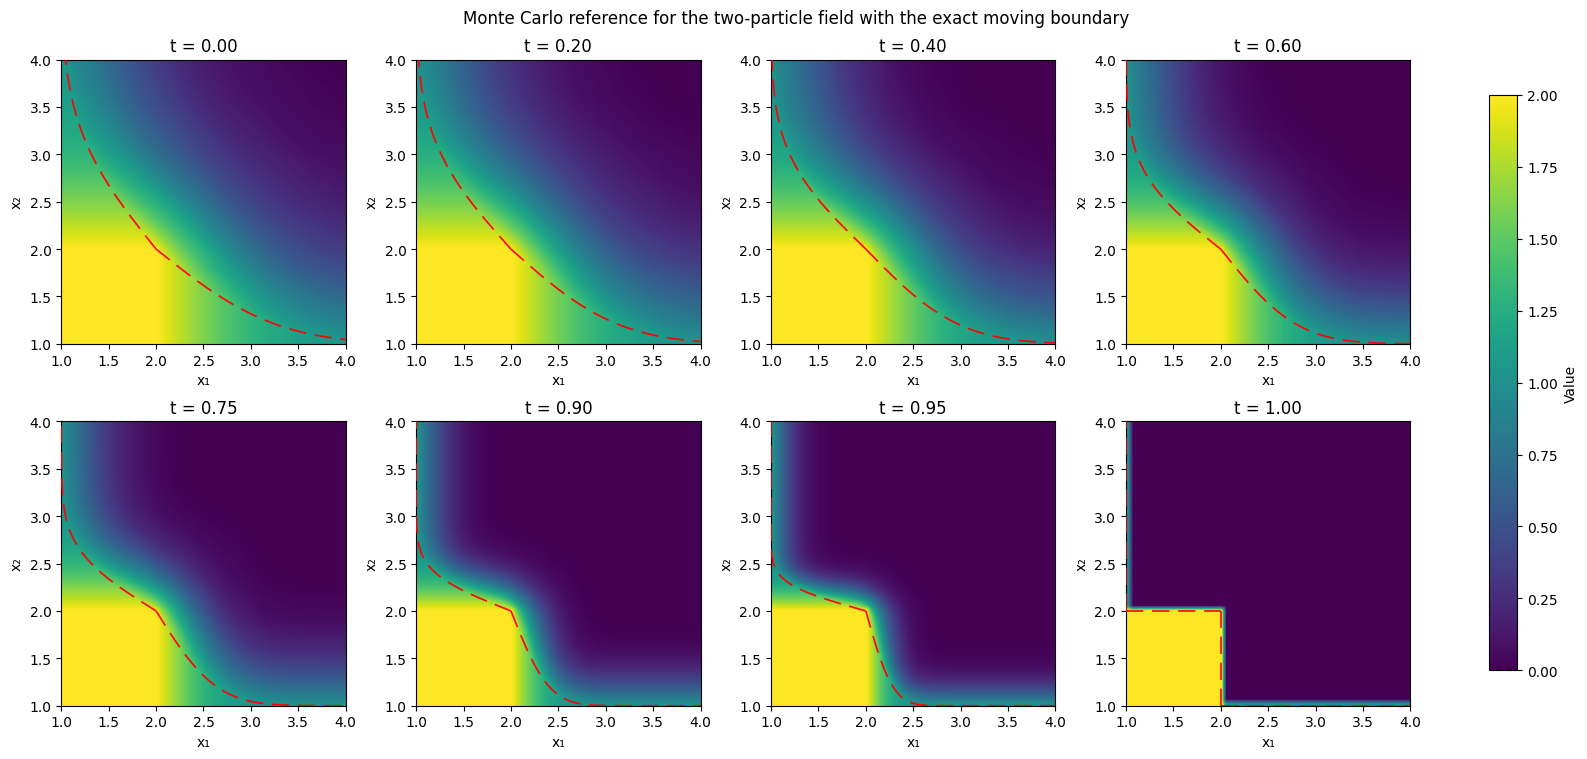

,time,Mean Monte Carlo SE,Maximum Monte Carlo SE
0,0.00,0.009544,0.013396
1,0.20,0.008908,0.013642
2,0.40,0.008089,0.014167
3,0.60,0.006883,0.014425
4,0.75,0.005654,0.015025
5,0.90,0.003772,0.015676
6,0.95,0.002866,0.015938
7,1.00,0.000000,0.000000


In [9]:
reference_dir = RESULTS_DIR / "01_reference"

fig, axes = plt.subplots(
    2, 4, figsize=(15.8, 7.5), constrained_layout=True
)
image = None

for ax, t_value in zip(axes.flat, CASCADE.geometry_times):
    reference = reference_surfaces[float(t_value)]
    axis_np = tensor_to_numpy(reference["axis"])
    field = tensor_to_numpy(reference["field"]).reshape(
        CASCADE.reference_grid_size,
        CASCADE.reference_grid_size,
    )

    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]],
        aspect="equal",
        interpolation="bilinear",
        cmap="viridis",
        vmin=0.0,
        vmax=2.0,
    )
    plot_exact_boundary(ax, float(t_value))
    ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
    ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"t = {t_value:.2f}")

if image is None:
    raise RuntimeError("Reference figure has no panels.")

colorbar = fig.colorbar(image, ax=axes, shrink=0.86)
colorbar.set_label("Value")
fig.suptitle(
    "Monte Carlo reference for the two-particle field with the exact moving boundary"
)
save_figure(
    fig,
    reference_dir / "reference_field_eight_times.pdf",
)

reference_uncertainty_rows = []
for t_value in CASCADE.geometry_times:
    reference = reference_surfaces[float(t_value)]
    inside = reference["inside"]
    standard_error = reference["standard_error"]
    inside_se = standard_error[inside]
    reference_uncertainty_rows.append({
        "time": float(t_value),
        "Mean Monte Carlo SE": float(inside_se.mean()) if inside_se.numel() else 0.0,
        "Maximum Monte Carlo SE": float(inside_se.max()) if inside_se.numel() else 0.0,
    })

reference_uncertainty = pd.DataFrame(reference_uncertainty_rows)
reference_uncertainty.to_csv(
    reference_dir / "reference_monte_carlo_uncertainty.csv", index=False
)
display(reference_uncertainty.round(6))


### 2.1 Stopped objective used by the exact-boundary benchmark and cascade-based method

In [10]:
def n2_stop_target(
    batch: BrownianBatch,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    boundary_value_provider: Callable[[Tensor, Tensor], Tensor],
    *,
    no_exit_value: float,
) -> tuple[Tensor, Tensor, Tensor]:
    smaller = batch.paths.min(dim=2).values
    larger = batch.paths.max(dim=2).values

    thresholds = boundary_provider(batch.times, larger)
    boundary_values = boundary_value_provider(batch.times, larger)

    breach = smaller <= thresholds
    stop_index, hit = first_true_index(breach)

    gather_index = stop_index.unsqueeze(1)
    stopped_boundary_value = boundary_values.gather(
        1, gather_index
    ).squeeze(1)

    target = torch.where(
        hit,
        stopped_boundary_value,
        torch.full_like(stopped_boundary_value, no_exit_value),
    )
    return stop_index, target, hit


def n2_loss(
    *,
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    boundary_value_provider: Callable[[Tensor, Tensor], Tensor],
    terminal_value: float,
    boundary_sample_time: Tensor,
    remaining_coordinate: Tensor,
    terminal_points: Tensor,
    terminal_mask_function: Callable[[Tensor], Tensor],
) -> tuple[Tensor, dict[str, Tensor]]:
    with torch.no_grad():
        stop_index, target, _ = n2_stop_target(
            batch,
            boundary_provider,
            boundary_value_provider,
            no_exit_value=terminal_value,
        )

    stopped_y = forward_two_particle(model, batch, stop_index)
    path_loss = (stopped_y - target).square().mean()

    with torch.no_grad():
        threshold = boundary_provider(boundary_sample_time, remaining_coordinate)
        boundary_value = boundary_value_provider(boundary_sample_time, remaining_coordinate)

    point_one = torch.stack((threshold, remaining_coordinate), dim=1)
    point_two = torch.stack((remaining_coordinate, threshold), dim=1)
    boundary_condition_loss = 0.5 * (
        (
            model.value(boundary_sample_time, point_one)
            - boundary_value
        ).square().mean()
        +
        (
            model.value(boundary_sample_time, point_two)
            - boundary_value
        ).square().mean()
    )

    with torch.no_grad():
        terminal_inside = terminal_mask_function(terminal_points)
    terminal_prediction = model.value(
        CASCADE.terminal_time, terminal_points
    )
    terminal_loss = masked_mean(
        (terminal_prediction - terminal_value).square(),
        terminal_inside,
    )

    total = path_loss + boundary_condition_loss + terminal_loss
    return total, {
        "path": path_loss,
        "boundary_condition": boundary_condition_loss,
        "terminal": terminal_loss,
    }


def sample_n2_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
) -> tuple[BrownianBatch, Tensor, Tensor, Tensor]:
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=2,
        steps=CASCADE.train_steps,
        x_min=CASCADE.x_min,
        x_max=CASCADE.x_max,
        max_start_time=CASCADE.max_start_time,
        sigma=CASCADE.sigma,
        generator=generator,
        antithetic=antithetic,
    )
    boundary_sample_time = uniform(
        (batch_size,), 0.0, CASCADE.max_start_time, generator
    )
    remaining_coordinate = uniform(
        (batch_size,), 2.001, CASCADE.x_max, generator
    )
    terminal_points = uniform(
        (batch_size, 2), CASCADE.x_min, CASCADE.x_max, generator
    )
    return batch, boundary_sample_time, remaining_coordinate, terminal_points


@torch.no_grad()
def completed_n2_value(
    *,
    model: SymmetricTwoParticleFBSDE,
    t: float | Tensor,
    points: Tensor,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    boundary_value_provider: Callable[[Tensor, Tensor], Tensor],
    terminal_value: float,
) -> Tensor:
    t_tensor = torch.as_tensor(
        t, device=points.device, dtype=points.dtype
    )
    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(points.shape[0])

    raw = model.value(t_tensor, points)
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    threshold = boundary_provider(t_tensor, larger)
    boundary_value = boundary_value_provider(t_tensor, larger)
    inside = smaller > threshold

    terminal_mask = (
        torch.abs(t_tensor - CASCADE.terminal_time)
        <= 1.0e-12
    )
    raw = torch.where(
        terminal_mask,
        torch.full_like(raw, terminal_value),
        raw,
    )
    return torch.where(inside, raw, boundary_value)


@torch.no_grad()
def model_surface(
    *,
    model: SymmetricTwoParticleFBSDE,
    time_value: float,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    boundary_value_provider: Callable[[Tensor, Tensor], Tensor],
    terminal_value: float,
) -> tuple[np.ndarray, np.ndarray]:
    axis = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        CASCADE.model_plot_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

    field = completed_n2_value(
        model=model,
        t=time_value,
        points=points,
        boundary_provider=boundary_provider,
        boundary_value_provider=boundary_value_provider,
        terminal_value=terminal_value,
    ).reshape(
        CASCADE.model_plot_grid_size,
        CASCADE.model_plot_grid_size,
    )
    return tensor_to_numpy(axis), tensor_to_numpy(field)

## 3 Exact-boundary benchmark

In [11]:
exact_boundary_dir = RESULTS_DIR / "02_exact_boundary_benchmark"
seed_everything(SEED + 200)

exact_boundary_model = SymmetricTwoParticleFBSDE(
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

exact_boundary_provider = (
    lambda t, r: exact_boundary_value(t, r)
)
exact_boundary_value_provider = (
    lambda t, r: exact_singleton_value(t, r)
)

exact_boundary_train_generator = make_generator(SEED + 201)
exact_boundary_validation_generator = make_generator(SEED + 202)
exact_boundary_validation_data = sample_n2_training_data(
    batch_size=CASCADE.validation_size,
    generator=exact_boundary_validation_generator,
    antithetic=False,
)


def exact_boundary_train_objective(model: nn.Module) -> Tensor:
    data = sample_n2_training_data(
        batch_size=OPTIM.batch_size,
        generator=exact_boundary_train_generator,
        antithetic=True,
    )
    total, _ = n2_loss(
        model=model,
        batch=data[0],
        boundary_provider=exact_boundary_provider,
        boundary_value_provider=exact_boundary_value_provider,
        terminal_value=0.0,
        boundary_sample_time=data[1],
        remaining_coordinate=data[2],
        terminal_points=data[3],
        terminal_mask_function=exact_terminal_domain_mask,
    )
    return total


def exact_boundary_validation_objective(model: nn.Module) -> Tensor:
    total, _ = n2_loss(
        model=model,
        batch=exact_boundary_validation_data[0],
        boundary_provider=exact_boundary_provider,
        boundary_value_provider=exact_boundary_value_provider,
        terminal_value=0.0,
        boundary_sample_time=exact_boundary_validation_data[1],
        remaining_coordinate=exact_boundary_validation_data[2],
        terminal_points=exact_boundary_validation_data[3],
        terminal_mask_function=exact_terminal_domain_mask,
    )
    return total


exact_boundary_training = train(
    model=exact_boundary_model,
    name="exact_boundary_benchmark",
    output_dir=exact_boundary_dir,
    train_objective=exact_boundary_train_objective,
    validation_objective=exact_boundary_validation_objective,
    iterations=OPTIM.iterations,
    learning_rate=OPTIM.learning_rate,
    validation_every=OPTIM.validation_every,
    display_every=OPTIM.display_every,
    scheduler_step=OPTIM.scheduler_step,
    scheduler_gamma=OPTIM.scheduler_gamma,
    gradient_clip=OPTIM.gradient_clip,
)
exact_boundary_model.eval()

plot_training_history(
    exact_boundary_training,
    "Exact-boundary benchmark training",
    exact_boundary_dir / "training_history.pdf",
)

display(pd.DataFrame({
    "diagnostic": [
        "Best iteration",
        "Best validation loss",
        "Runtime in minutes",
    ],
    "value": [
        exact_boundary_training.best_iteration,
        exact_boundary_training.best_validation_loss,
        exact_boundary_training.runtime_seconds / 60.0,
    ],
}))

exact_boundary_benchmark           iteration   200 train 4.809514e-01 val 4.860149e-01
exact_boundary_benchmark           iteration   400 train 4.680241e-01 val 4.410747e-01
exact_boundary_benchmark           iteration   600 train 3.649977e-01 val 3.940536e-01
exact_boundary_benchmark           iteration   800 train 2.812978e-01 val 2.807822e-01
exact_boundary_benchmark           iteration  1000 train 2.651366e-01 val 2.836628e-01
exact_boundary_benchmark           iteration  1200 train 2.452375e-01 val 2.436039e-01
exact_boundary_benchmark           iteration  1400 train 2.258342e-01 val 2.310944e-01
exact_boundary_benchmark           iteration  1600 train 2.110668e-01 val 2.073539e-01
exact_boundary_benchmark           iteration  1800 train 1.552745e-01 val 1.835678e-01
exact_boundary_benchmark           iteration  2000 train 1.541496e-01 val 1.543375e-01
exact_boundary_benchmark           iteration  2200 train 1.445000e-01 val 1.387252e-01
exact_boundary_benchmark           iteratio

,diagnostic,value
0,Best iteration,14800.000000
1,Best validation loss,0.020813
2,Runtime in minutes,20.969847


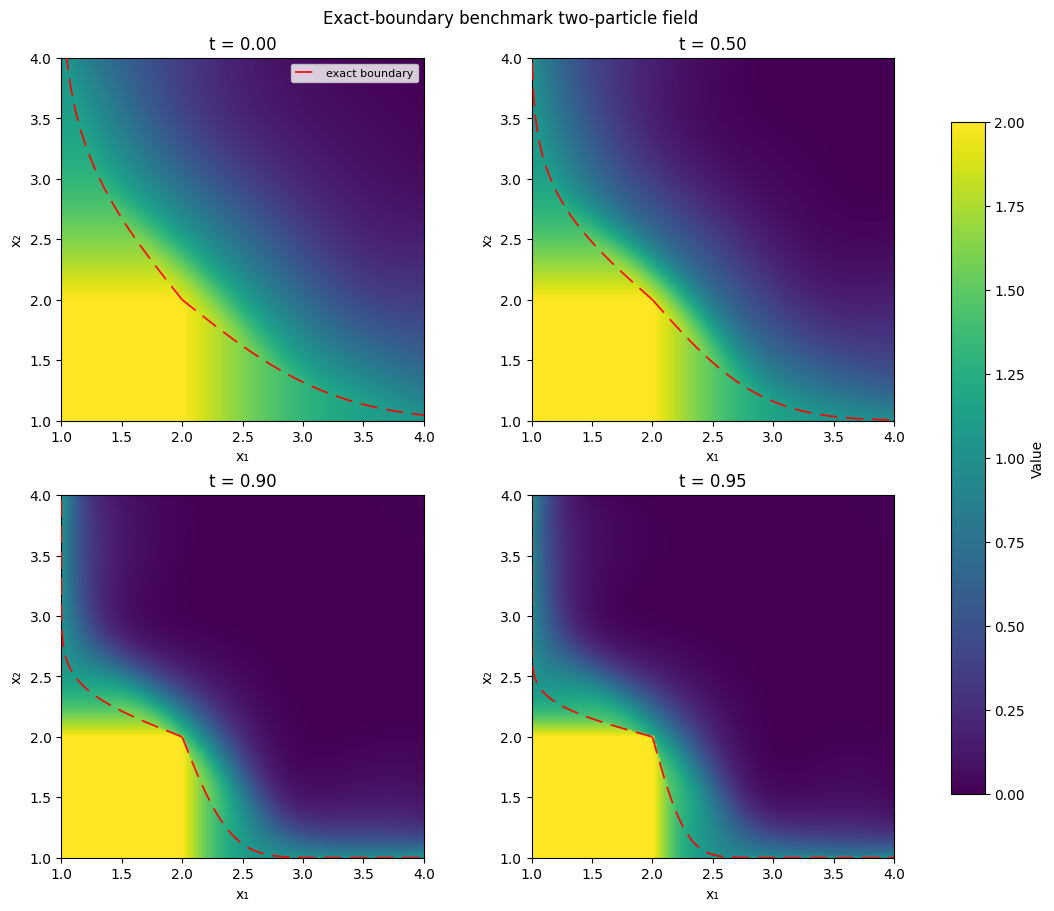

In [12]:
exact_boundary_surfaces = {
    float(t_value): model_surface(
        model=exact_boundary_model,
        time_value=float(t_value),
        boundary_provider=exact_boundary_provider,
        boundary_value_provider=exact_boundary_value_provider,
        terminal_value=0.0,
    )
    for t_value in CASCADE.comparison_times
}


def exact_boundary_boundary_plotter(
    ax: plt.Axes, t_value: float
) -> None:
    plot_exact_boundary(
        ax,
        t_value,
        label="exact boundary",
    )


plot_four_heatmaps(
    surfaces=exact_boundary_surfaces,
    title="Exact-boundary benchmark two-particle field",
    output_path=exact_boundary_dir / "exact_boundary_benchmark_field_four_times.pdf",
    boundary_plotter=exact_boundary_boundary_plotter,
)

## 4 Direct Deep BSDE application

In [13]:
@torch.no_grad()
def direct_independent_diagnostics(
    model: DirectGlobalFBSDE,
) -> dict[str, float | bool]:
    reference = reference_surfaces[0.0]
    points = reference["points"].to(DEVICE)
    true_field = reference["field"].to(DEVICE)
    exact_inside = reference["inside"].to(DEVICE)

    prediction = model.aggregate_value(points)
    smaller = points.min(dim=1).values
    predicted_inside = smaller > CASCADE.alpha * prediction
    level_set = smaller - CASCADE.alpha * prediction
    interior_error = prediction[exact_inside] - true_field[exact_inside]

    return {
        "Field MAE": float(interior_error.abs().mean().cpu()),
        "Field RMSE": float(
            torch.sqrt(interior_error.square().mean()).cpu()
        ),
        "Domain accuracy": float(
            (predicted_inside == exact_inside).to(DTYPE).mean().cpu()
        ),
        "Aggregate minimum": float(prediction.min().cpu()),
        "Aggregate maximum": float(prediction.max().cpu()),
        "Range violation rate": float(
            ((prediction < 0.0) | (prediction > 2.0))
            .to(DTYPE).mean().cpu()
        ),
        "Implicit boundary exists": bool(
            float(level_set.min().cpu()) <= 0.0
            and float(level_set.max().cpu()) >= 0.0
        ),
    }


def train_direct_model(
    *,
    model: DirectGlobalFBSDE,
    seed: int,
    output_dir: Path,
    validation_batch: BrownianBatch,
) -> TrainingResult:
    output_dir.mkdir(parents=True, exist_ok=True)
    history_path = output_dir / "direct_deep_bsde_history.csv"

    train_generator = make_generator(seed + 10_000)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=OPTIM.learning_rate
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=OPTIM.scheduler_step,
        gamma=OPTIM.scheduler_gamma,
    )

    best_validation = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    records: list[dict[str, float]] = []
    start = time.time()

    for iteration in range(1, OPTIM.iterations + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        batch = sample_brownian_batch(
            batch_size=OPTIM.batch_size,
            dimension=2,
            steps=CASCADE.train_steps,
            x_min=CASCADE.x_min,
            x_max=CASCADE.x_max,
            max_start_time=0.0,
            sigma=CASCADE.sigma,
            generator=train_generator,
            antithetic=OPTIM.direct_antithetic,
        )
        loss = direct_global_loss(model, batch)
        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite direct Deep BSDE loss")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), OPTIM.gradient_clip
        )
        optimizer.step()
        scheduler.step()

        if (
            iteration % OPTIM.validation_every == 0
            or iteration == OPTIM.iterations
        ):
            model.eval()
            with torch.no_grad():
                validation_loss = float(
                    direct_global_loss(model, validation_batch).item()
                )

            records.append({
                "iteration": iteration,
                "training_loss": float(loss.item()),
                "validation_loss": validation_loss,
            })

            print(
                f"Direct Deep BSDE iteration {iteration:5d} "
                f"train {float(loss.item()):.6e} "
                f"val {validation_loss:.6e}"
            )

            # The exact solution is not used for model selection.
            if validation_loss < best_validation:
                best_validation = validation_loss
                best_iteration = iteration
                best_state = copy.deepcopy(model.state_dict())

    runtime = time.time() - start
    model.load_state_dict(best_state)
    history = pd.DataFrame(records)
    history.to_csv(history_path, index=False)
    return TrainingResult(
        best_iteration=best_iteration,
        best_validation_loss=best_validation,
        runtime_seconds=runtime,
        history=history,
    )

In [14]:
direct_dir = RESULTS_DIR / "03_direct_deep_bsde"
direct_dir.mkdir(parents=True, exist_ok=True)

seed_everything(OPTIM.direct_seed)
direct_model = DirectGlobalFBSDE(
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

direct_validation_generator = make_generator(SEED + 1_100)
direct_validation_batch = sample_brownian_batch(
    batch_size=CASCADE.validation_size,
    dimension=2,
    steps=CASCADE.train_steps,
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    max_start_time=0.0,
    sigma=CASCADE.sigma,
    generator=direct_validation_generator,
    antithetic=False,
)

direct_training = train_direct_model(
    model=direct_model,
    seed=OPTIM.direct_seed,
    output_dir=direct_dir,
    validation_batch=direct_validation_batch,
)
direct_model.eval()

direct_diagnostics = direct_independent_diagnostics(direct_model)
direct_path_diagnostics = direct_rollout_range_diagnostics(
    direct_model, direct_validation_batch
)
direct_summary = pd.DataFrame([{
    "Seed": OPTIM.direct_seed,
    "Best iteration": direct_training.best_iteration,
    "Deep BSDE validation loss": direct_training.best_validation_loss,
    **direct_diagnostics,
    **direct_path_diagnostics,
    "Runtime minutes": direct_training.runtime_seconds / 60.0,
}])
direct_summary.to_csv(direct_dir / "direct_deep_bsde_summary.csv", index=False)
display(direct_summary)

Direct Deep BSDE iteration   200 train 4.905275e-02 val 5.000919e-02
Direct Deep BSDE iteration   400 train 3.904639e-02 val 3.966578e-02
Direct Deep BSDE iteration   600 train 3.467879e-02 val 3.402169e-02
Direct Deep BSDE iteration   800 train 2.746838e-02 val 2.728171e-02
Direct Deep BSDE iteration  1000 train 2.201947e-02 val 2.266884e-02
Direct Deep BSDE iteration  1200 train 1.939118e-02 val 1.934163e-02
Direct Deep BSDE iteration  1400 train 1.865115e-02 val 1.774285e-02
Direct Deep BSDE iteration  1600 train 1.690661e-02 val 1.656545e-02
Direct Deep BSDE iteration  1800 train 1.589450e-02 val 1.579906e-02
Direct Deep BSDE iteration  2000 train 1.419256e-02 val 1.527001e-02
Direct Deep BSDE iteration  2200 train 1.455426e-02 val 1.454103e-02
Direct Deep BSDE iteration  2400 train 1.310643e-02 val 1.333964e-02
Direct Deep BSDE iteration  2600 train 1.164478e-02 val 1.285572e-02
Direct Deep BSDE iteration  2800 train 1.348247e-02 val 1.191837e-02
Direct Deep BSDE iteration  3000 t

,Seed,Best iteration,Deep BSDE validation loss,Field MAE,Field RMSE,Domain accuracy,Aggregate minimum,Aggregate maximum,Range violation rate,Implicit boundary exists,path_range_violation_rate,path_value_minimum,path_value_maximum,Runtime minutes
0,123,15000,0.005753,0.25396,0.308833,0.903252,0.011539,2.056102,0.054555,True,0.206887,-0.558631,1.617209,14.984409


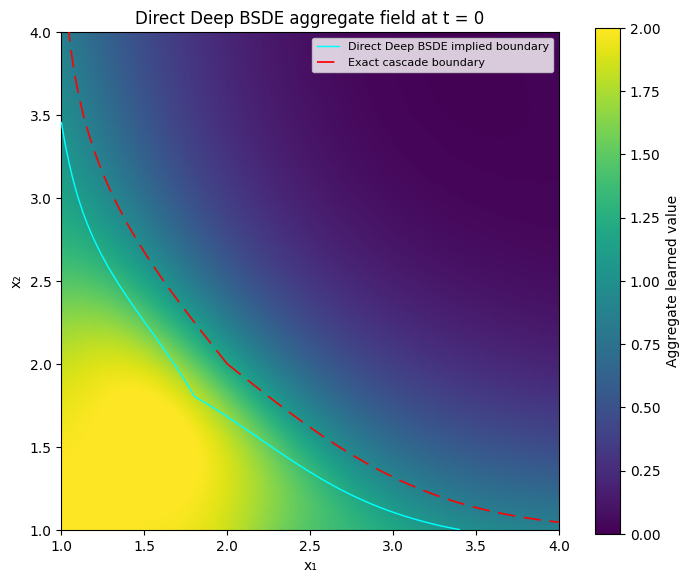

In [15]:
@torch.no_grad()
def direct_surface(
    model: DirectGlobalFBSDE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    axis = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        CASCADE.model_plot_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
    field = model.aggregate_value(points).reshape(
        CASCADE.model_plot_grid_size,
        CASCADE.model_plot_grid_size,
    )
    level_set = torch.minimum(x1, x2) - CASCADE.alpha * field
    return tensor_to_numpy(axis), tensor_to_numpy(field), tensor_to_numpy(level_set)


direct_axis, direct_field, direct_level_set = direct_surface(direct_model)

fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
image = ax.imshow(
    direct_field.T,
    origin="lower",
    extent=[direct_axis[0], direct_axis[-1], direct_axis[0], direct_axis[-1]],
    aspect="equal",
    interpolation="bilinear",
    cmap="viridis",
    vmin=0.0,
    vmax=2.0,
)

contour_exists = (
    np.nanmin(direct_level_set) <= 0.0
    and np.nanmax(direct_level_set) >= 0.0
)
if contour_exists:
    ax.contour(
        direct_axis,
        direct_axis,
        direct_level_set.T,
        levels=[0.0],
        colors=["cyan"],
        linestyles="-",
        linewidths=1.05,
        zorder=6,
    )

plot_exact_boundary(ax, 0.0)
ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
ax.set_aspect("equal")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_title("Direct Deep BSDE aggregate field at t = 0")
fig.colorbar(image, ax=ax, label="Aggregate learned value")

legend_handles = [
    Line2D([0], [0], color="red", linestyle=(0, (10, 5)), linewidth=1.25,
           label="Exact cascade boundary"),
]
if contour_exists:
    legend_handles.insert(
        0,
        Line2D([0], [0], color="cyan", linestyle="-", linewidth=1.05,
               label="Direct Deep BSDE implied boundary"),
    )
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")
save_figure(fig, direct_dir / "direct_deep_bsde_heatmap_t0.pdf")

## 5 Cascade-based learned-boundary method

### 5.1 Learn and freeze the singleton field

In [16]:
def singleton_loss(
    *,
    model: BoundedSingletonFBSDE,
    batch: BrownianBatch,
    boundary_time: Tensor,
    terminal_x: Tensor,
    monotone_time: Tensor,
    monotone_x: Tensor,
) -> tuple[Tensor, dict[str, Tensor]]:
    threshold = 2.0 * CASCADE.alpha
    breach = batch.paths[:, :, 0] <= threshold
    stop_index, hit = first_true_index(breach)

    target = torch.where(
        hit,
        torch.full_like(batch.start_time, 2.0),
        torch.full_like(batch.start_time, 1.0),
    )
    stopped_y = forward_singleton(
        model, batch, stop_index
    )
    path_loss = (stopped_y - target).square().mean()

    boundary_prediction = model.value(
        boundary_time,
        torch.full_like(boundary_time, threshold),
    )
    boundary_loss = (
        boundary_prediction - 2.0
    ).square().mean()

    terminal_prediction = model.value(
        CASCADE.terminal_time, terminal_x
    )
    terminal_loss = (
        terminal_prediction - 1.0
    ).square().mean()

    monotone_x = monotone_x.detach().clone().requires_grad_(True)
    monotone_prediction = model.value(
        monotone_time, monotone_x
    )
    derivative = torch.autograd.grad(
        monotone_prediction.sum(),
        monotone_x,
        create_graph=True,
    )[0]
    monotonicity_loss = torch.relu(
        derivative
    ).square().mean()

    total = (
        path_loss
        + boundary_loss
        + terminal_loss
        + 0.25 * monotonicity_loss
    )
    return total, {
        "path": path_loss,
        "boundary": boundary_loss,
        "terminal": terminal_loss,
        "monotonicity": monotonicity_loss,
    }


def sample_singleton_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
) -> tuple[BrownianBatch, Tensor, Tensor, Tensor, Tensor]:
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=1,
        steps=CASCADE.train_steps,
        x_min=CASCADE.singleton_x_min,
        x_max=CASCADE.x_max,
        max_start_time=CASCADE.max_start_time,
        sigma=CASCADE.sigma,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_time = uniform(
        (batch_size,),
        0.0,
        CASCADE.max_start_time,
        generator,
    )
    terminal_x = uniform(
        (batch_size,),
        2.0 * CASCADE.alpha + 0.001,
        CASCADE.x_max,
        generator,
    )

    terminal_bias = torch.rand(
        batch_size,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    ).square()
    monotone_time = (
        CASCADE.max_start_time
        * (1.0 - terminal_bias)
    )
    spatial_bias = torch.rand(
        batch_size,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    ).square()
    monotone_x = (
        2.0 * CASCADE.alpha
        + 0.001
        + (
            CASCADE.x_max
            - 2.0 * CASCADE.alpha
            - 0.001
        ) * spatial_bias
    )

    return (
        batch,
        boundary_time,
        terminal_x,
        monotone_time,
        monotone_x,
    )

In [17]:
singleton_dir = RESULTS_DIR / "04_cascade_singleton"
seed_everything(SEED + 500)

singleton_model = BoundedSingletonFBSDE(
    x_min=2.0 * CASCADE.alpha,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

singleton_train_generator = make_generator(SEED + 501)
singleton_validation_generator = make_generator(SEED + 502)
singleton_validation_data = sample_singleton_training_data(
    batch_size=CASCADE.validation_size,
    generator=singleton_validation_generator,
    antithetic=False,
)


def singleton_train_objective(
    model: nn.Module,
) -> Tensor:
    data = sample_singleton_training_data(
        batch_size=OPTIM.batch_size,
        generator=singleton_train_generator,
        antithetic=True,
    )
    total, _ = singleton_loss(
        model=model,
        batch=data[0],
        boundary_time=data[1],
        terminal_x=data[2],
        monotone_time=data[3],
        monotone_x=data[4],
    )
    return total


def singleton_validation_objective(
    model: nn.Module,
) -> Tensor:
    with torch.enable_grad():
        total, _ = singleton_loss(
            model=model,
            batch=singleton_validation_data[0],
            boundary_time=singleton_validation_data[1],
            terminal_x=singleton_validation_data[2],
            monotone_time=singleton_validation_data[3],
            monotone_x=singleton_validation_data[4],
        )
    return total


singleton_training = train(
    model=singleton_model,
    name="cascade_singleton",
    output_dir=singleton_dir,
    train_objective=singleton_train_objective,
    validation_objective=singleton_validation_objective,
    iterations=OPTIM.iterations,
    learning_rate=OPTIM.learning_rate,
    validation_every=OPTIM.validation_every,
    display_every=OPTIM.display_every,
    scheduler_step=OPTIM.scheduler_step,
    scheduler_gamma=OPTIM.scheduler_gamma,
    gradient_clip=OPTIM.gradient_clip,
)

plot_training_history(
    singleton_training,
    "Cascade singleton stopped training",
    singleton_dir / "training_history.pdf",
)

singleton_model.eval()
for parameter in singleton_model.parameters():
    parameter.requires_grad_(False)


@torch.no_grad()
def learned_singleton_value(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    t_tensor = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    t_tensor, x_tensor = torch.broadcast_tensors(
        t_tensor, x
    )
    raw = singleton_model.value(
        t_tensor.reshape(-1),
        x_tensor.reshape(-1),
    ).reshape(x_tensor.shape)

    return torch.where(
        x_tensor <= 2.0 * CASCADE.alpha,
        torch.full_like(raw, 2.0),
        raw,
    )


def learned_boundary_value(
    t: float | Tensor,
    remaining_coordinate: Tensor,
) -> Tensor:
    return CASCADE.alpha * learned_singleton_value(
        t, remaining_coordinate
    )


display(pd.DataFrame({
    "diagnostic": [
        "Best iteration",
        "Best validation loss",
        "Runtime in minutes",
    ],
    "value": [
        singleton_training.best_iteration,
        singleton_training.best_validation_loss,
        singleton_training.runtime_seconds / 60.0,
    ],
}))

cascade_singleton                  iteration   200 train 7.177061e-02 val 7.994994e-02
cascade_singleton                  iteration   400 train 6.548971e-02 val 6.868273e-02
cascade_singleton                  iteration   600 train 5.547116e-02 val 5.682116e-02
cascade_singleton                  iteration   800 train 5.960044e-02 val 5.472441e-02
cascade_singleton                  iteration  1000 train 5.600519e-02 val 5.237176e-02
cascade_singleton                  iteration  1200 train 5.128264e-02 val 5.112749e-02
cascade_singleton                  iteration  1400 train 4.589780e-02 val 4.636856e-02
cascade_singleton                  iteration  1600 train 3.931151e-02 val 3.985330e-02
cascade_singleton                  iteration  1800 train 3.107002e-02 val 3.300143e-02
cascade_singleton                  iteration  2000 train 2.673459e-02 val 2.782203e-02
cascade_singleton                  iteration  2200 train 2.441105e-02 val 2.322203e-02
cascade_singleton                  iteratio

,diagnostic,value
0,Best iteration,15000.000000
1,Best validation loss,0.007531
2,Runtime in minutes,12.694577


### 5.2 Moving boundary determined by the learned singleton field

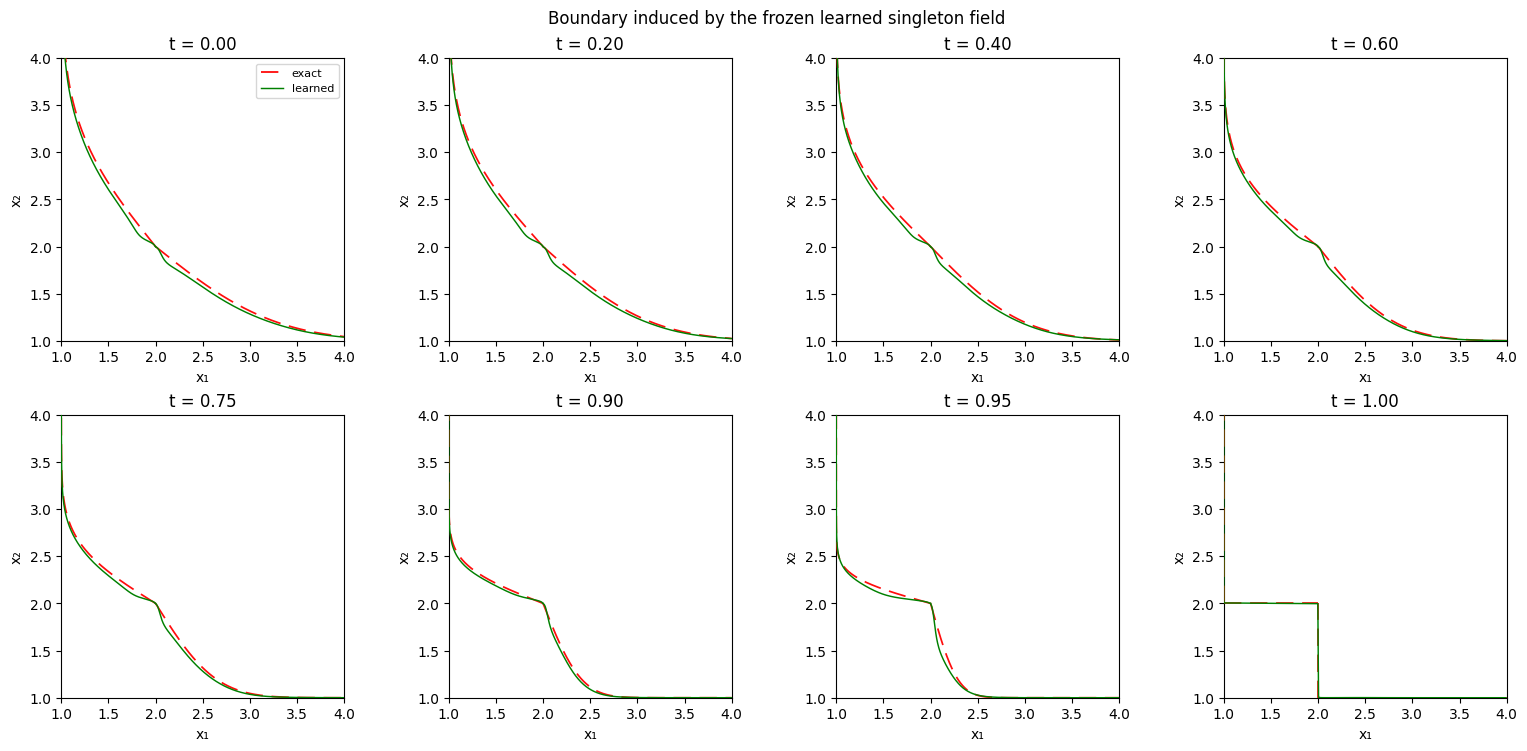

,time,Threshold MAE,Threshold RMSE,Maximum threshold error
0,0.00,0.032554,0.037821,0.078471
1,0.20,0.028520,0.035561,0.078051
2,0.40,0.026014,0.034470,0.077628
3,0.60,0.022017,0.031485,0.079607
4,0.75,0.020003,0.031826,0.088462
5,0.90,0.012743,0.023689,0.069271
6,0.95,0.015442,0.040828,0.166745
7,1.00,0.000318,0.000659,0.008597


In [18]:
fig, axes = plt.subplots(
    2, 4, figsize=(15.5, 7.4), constrained_layout=True
)
boundary_rows: list[dict[str, float]] = []

# Threshold-error grid on the non-trivial remaining_coordinate branch.  These diagnostics
# are different from the full point-cloud boundary distances used later.
diagnostic_remaining_coordinate = torch.linspace(
    2.001,
    CASCADE.x_max,
    800,
    device=DEVICE,
    dtype=DTYPE,
)

for ax, t_value in zip(axes.flat, CASCADE.geometry_times):
    # Exact topological boundary, including the special terminal geometry.
    plot_exact_boundary(ax, float(t_value), label="exact")

    if t_value < CASCADE.terminal_time:
        # For t<T the learned boundary is a genuine graph only on the feasible
        # remaining_coordinate branch r>=2*alpha.
        plot_graph_boundary(
            ax,
            float(t_value),
            learned_boundary_value,
            color="green",
            linestyle="-",
            linewidth=1.05,
            label="learned",
        )
    else:
        # At T the completed singleton field jumps at r=2.  Use the zero
        # contour of min(x)-b(T,max(x)) so the terminal closure segment is
        # represented rather than drawing an infeasible graph extension.
        terminal_axis = torch.linspace(
            CASCADE.x_min,
            CASCADE.x_max,
            401,
            device=DEVICE,
            dtype=DTYPE,
        )
        x1, x2 = torch.meshgrid(terminal_axis, terminal_axis, indexing="ij")
        terminal_points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
        smaller = terminal_points.min(dim=1).values
        larger = terminal_points.max(dim=1).values
        level = (
            smaller
            - learned_boundary_value(CASCADE.terminal_time, larger)
        ).reshape(401, 401)
        axis_np = tensor_to_numpy(terminal_axis)
        ax.contour(
            axis_np,
            axis_np,
            tensor_to_numpy(level).T,
            levels=[0.0],
            colors=["green"],
            linestyles="-",
            linewidths=1.05,
            zorder=6,
        )

    ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
    ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"t = {t_value:.2f}")

    exact = exact_boundary_value(t_value, diagnostic_remaining_coordinate)
    learned = learned_boundary_value(t_value, diagnostic_remaining_coordinate)
    error = learned - exact
    boundary_rows.append({
        "time": float(t_value),
        "Threshold MAE": float(error.abs().mean().cpu()),
        "Threshold RMSE": float(torch.sqrt(error.square().mean()).cpu()),
        "Maximum threshold error": float(error.abs().max().cpu()),
    })

legend_handles = [
    Line2D([0], [0], color="red", linestyle=(0, (10, 5)), linewidth=1.25,
           label="exact"),
    Line2D([0], [0], color="green", linestyle="-", linewidth=1.05,
           label="learned"),
]
axes.flat[0].legend(handles=legend_handles, fontsize=8)
fig.suptitle("Boundary induced by the frozen learned singleton field")
save_figure(fig, singleton_dir / "learned_boundary_eight_times.pdf")

singleton_boundary_metrics = pd.DataFrame(boundary_rows)
singleton_boundary_metrics.to_csv(
    singleton_dir / "boundary_metrics.csv", index=False
)
display(singleton_boundary_metrics.round(6))


### 5.3 Learn the two-particle field inside the frozen learned domain

In [19]:
cascade_dir = RESULTS_DIR / "05_cascade_two_particle"
seed_everything(SEED + 600)

cascade_model = SymmetricTwoParticleFBSDE(
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

learned_boundary_provider = (
    lambda t, r: learned_boundary_value(t, r)
)
learned_boundary_value_provider = (
    lambda t, r: learned_singleton_value(t, r)
)

cascade_train_generator = make_generator(SEED + 601)
cascade_validation_generator = make_generator(SEED + 602)
cascade_validation_data = sample_n2_training_data(
    batch_size=CASCADE.validation_size,
    generator=cascade_validation_generator,
    antithetic=False,
)


def learned_terminal_domain_mask(
    points: Tensor,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    threshold = learned_boundary_value(
        torch.ones_like(larger), larger
    )
    return smaller > threshold


def cascade_train_objective(
    model: nn.Module,
) -> Tensor:
    data = sample_n2_training_data(
        batch_size=OPTIM.batch_size,
        generator=cascade_train_generator,
        antithetic=True,
    )
    total, _ = n2_loss(
        model=model,
        batch=data[0],
        boundary_provider=learned_boundary_provider,
        boundary_value_provider=learned_boundary_value_provider,
        terminal_value=0.0,
        boundary_sample_time=data[1],
        remaining_coordinate=data[2],
        terminal_points=data[3],
        terminal_mask_function=learned_terminal_domain_mask,
    )
    return total


def cascade_validation_objective(
    model: nn.Module,
) -> Tensor:
    total, _ = n2_loss(
        model=model,
        batch=cascade_validation_data[0],
        boundary_provider=learned_boundary_provider,
        boundary_value_provider=learned_boundary_value_provider,
        terminal_value=0.0,
        boundary_sample_time=cascade_validation_data[1],
        remaining_coordinate=cascade_validation_data[2],
        terminal_points=cascade_validation_data[3],
        terminal_mask_function=learned_terminal_domain_mask,
    )
    return total


cascade_training = train(
    model=cascade_model,
    name="cascade_two_particle",
    output_dir=cascade_dir,
    train_objective=cascade_train_objective,
    validation_objective=cascade_validation_objective,
    iterations=OPTIM.iterations,
    learning_rate=OPTIM.learning_rate,
    validation_every=OPTIM.validation_every,
    display_every=OPTIM.display_every,
    scheduler_step=OPTIM.scheduler_step,
    scheduler_gamma=OPTIM.scheduler_gamma,
    gradient_clip=OPTIM.gradient_clip,
)
cascade_model.eval()

plot_training_history(
    cascade_training,
    "Cascade-based two-particle training",
    cascade_dir / "training_history.pdf",
)

display(pd.DataFrame({
    "diagnostic": [
        "Best iteration",
        "Best validation loss",
        "Runtime in minutes",
    ],
    "value": [
        cascade_training.best_iteration,
        cascade_training.best_validation_loss,
        cascade_training.runtime_seconds / 60.0,
    ],
}))

cascade_two_particle               iteration   200 train 4.478308e-01 val 4.810503e-01
cascade_two_particle               iteration   400 train 4.290715e-01 val 4.403383e-01
cascade_two_particle               iteration   600 train 3.312855e-01 val 3.454791e-01
cascade_two_particle               iteration   800 train 2.584573e-01 val 2.718060e-01
cascade_two_particle               iteration  1000 train 2.536026e-01 val 2.595823e-01
cascade_two_particle               iteration  1200 train 2.420925e-01 val 2.472250e-01
cascade_two_particle               iteration  1400 train 2.316663e-01 val 2.423188e-01
cascade_two_particle               iteration  1600 train 2.532805e-01 val 2.362043e-01
cascade_two_particle               iteration  1800 train 2.315183e-01 val 2.316947e-01
cascade_two_particle               iteration  2000 train 2.029010e-01 val 2.293806e-01
cascade_two_particle               iteration  2200 train 2.125841e-01 val 2.212828e-01
cascade_two_particle               iteratio

,diagnostic,value
0,Best iteration,15000.000000
1,Best validation loss,0.027527
2,Runtime in minutes,21.306664


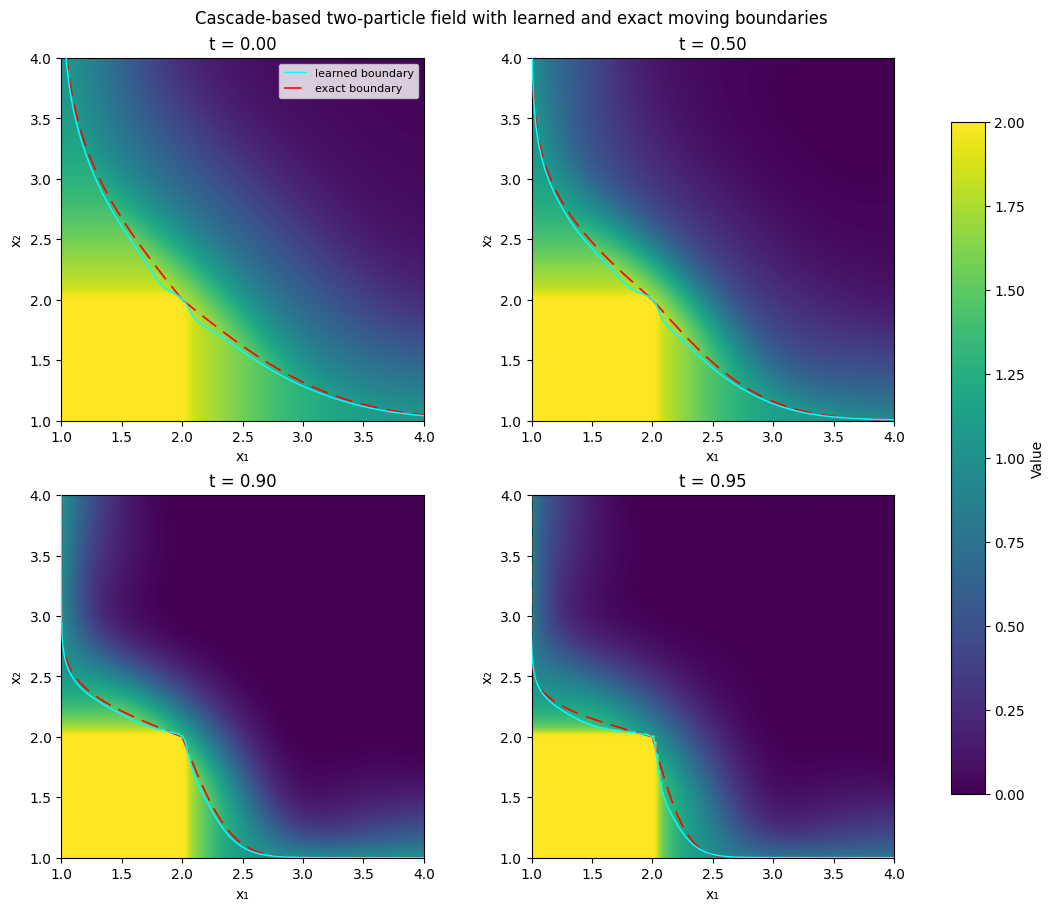

In [20]:
cascade_surfaces = {
    float(t_value): model_surface(
        model=cascade_model,
        time_value=float(t_value),
        boundary_provider=learned_boundary_provider,
        boundary_value_provider=learned_boundary_value_provider,
        terminal_value=0.0,
    )
    for t_value in CASCADE.comparison_times
}


def cascade_boundary_plotter(
    ax: plt.Axes, t_value: float
) -> None:
    plot_graph_boundary(
        ax,
        t_value,
        learned_boundary_value,
        color="cyan",
        linestyle="-",
        linewidth=1.05,
        label="learned boundary",
    )
    plot_exact_boundary(
        ax,
        t_value,
        label="exact boundary",
    )


plot_four_heatmaps(
    surfaces=cascade_surfaces,
    title="Cascade-based two-particle field with learned and exact moving boundaries",
    output_path=cascade_dir / "cascade_field_four_times.pdf",
    boundary_plotter=cascade_boundary_plotter,
)

## 6 Independent comparison

In [21]:
@torch.no_grad()
def exact_boundary_point_cloud(time_value: float) -> np.ndarray:
    curves = exact_boundary_curves(time_value)
    return np.concatenate(
        [np.column_stack((x_curve, y_curve))
         for x_curve, y_curve in curves],
        axis=0,
    )


@torch.no_grad()
def graph_boundary_point_cloud(
    time_value: float,
    boundary_function: Callable[[float, Tensor], Tensor],
) -> np.ndarray:
    remaining_coordinate, boundary = feasible_graph_branch(
        time_value, boundary_function, points=800
    )
    points = torch.cat(
        (
            torch.stack((boundary, remaining_coordinate), dim=1),
            torch.stack((remaining_coordinate, boundary), dim=1),
        ),
        dim=0,
    )
    inside_box = (
        (points[:, 0] >= CASCADE.x_min)
        & (points[:, 0] <= CASCADE.x_max)
        & (points[:, 1] >= CASCADE.x_min)
        & (points[:, 1] <= CASCADE.x_max)
    )
    return tensor_to_numpy(points[inside_box])


def implicit_boundary_point_cloud(
    axis: np.ndarray,
    level_set: np.ndarray,
) -> np.ndarray:
    points: list[np.ndarray] = []
    horizontal = level_set[:-1, :] * level_set[1:, :] <= 0.0
    i, j = np.where(horizontal)
    if i.size:
        points.append(np.column_stack((
            0.5 * (axis[i] + axis[i + 1]), axis[j]
        )))
    vertical = level_set[:, :-1] * level_set[:, 1:] <= 0.0
    i, j = np.where(vertical)
    if i.size:
        points.append(np.column_stack((
            axis[i], 0.5 * (axis[j] + axis[j + 1])
        )))
    if not points:
        return np.empty((0, 2))
    return np.concatenate(points, axis=0)


def point_cloud_metrics(
    candidate: np.ndarray,
    exact: np.ndarray,
) -> dict[str, float]:
    if candidate.shape[0] == 0:
        return {
            "Mean boundary distance": math.nan,
            "Boundary RMSE": math.nan,
            "Discrete point-cloud Hausdorff distance": math.nan,
        }
    candidate_tree = cKDTree(candidate)
    exact_tree = cKDTree(exact)
    exact_to_candidate = candidate_tree.query(exact, k=1)[0]
    candidate_to_exact = exact_tree.query(candidate, k=1)[0]
    combined = np.concatenate((exact_to_candidate, candidate_to_exact))
    return {
        "Mean boundary distance": float(combined.mean()),
        "Boundary RMSE": float(np.sqrt(np.mean(combined**2))),
        "Discrete point-cloud Hausdorff distance": float(combined.max()),
    }


@torch.no_grad()
def completed_exact_boundary_field(t_value: float, points: Tensor) -> Tensor:
    return completed_n2_value(
        model=exact_boundary_model,
        t=t_value,
        points=points,
        boundary_provider=exact_boundary_provider,
        boundary_value_provider=exact_boundary_value_provider,
        terminal_value=0.0,
    )


@torch.no_grad()
def completed_cascade_field(t_value: float, points: Tensor) -> Tensor:
    return completed_n2_value(
        model=cascade_model,
        t=t_value,
        points=points,
        boundary_provider=learned_boundary_provider,
        boundary_value_provider=learned_boundary_value_provider,
        terminal_value=0.0,
    )


def aggregate_range_diagnostics(
    prediction: Tensor,
    *,
    lower: float = 0.0,
    upper: float = 2.0,
) -> dict[str, float]:
    minimum = float(prediction.min().cpu())
    maximum = float(prediction.max().cpu())
    lower_excursion = max(0.0, lower - minimum)
    upper_excursion = max(0.0, maximum - upper)
    return {
        "Field minimum": minimum,
        "Field maximum": maximum,
        "Range violation rate": float(
            ((prediction < lower) | (prediction > upper))
            .to(DTYPE).mean().cpu()
        ),
        "Lower range excursion": lower_excursion,
        "Upper range excursion": upper_excursion,
        "Maximum range violation magnitude": max(
            lower_excursion, upper_excursion
        ),
    }


field_rows: list[dict[str, float | int | str]] = []
for t_value in CASCADE.comparison_times:
    reference = reference_surfaces[float(t_value)]
    points = reference["points"].to(DEVICE)
    exact_field = reference["field"].to(DEVICE)
    exact_inside = reference["inside"].to(DEVICE)

    for method, prediction, predicted_inside in (
        (
            "Exact-boundary benchmark",
            completed_exact_boundary_field(float(t_value), points),
            exact_inside,
        ),
        (
            "Cascade-based",
            completed_cascade_field(float(t_value), points),
            points.min(dim=1).values
            > learned_boundary_value(
                float(t_value), points.max(dim=1).values
            ),
        ),
    ):
        error = prediction[exact_inside] - exact_field[exact_inside]
        field_rows.append({
            "method": method,
            "seed": math.nan,
            "time": float(t_value),
            "Field MAE": float(error.abs().mean().cpu()),
            "Field RMSE": float(torch.sqrt(error.square().mean()).cpu()),
            "Maximum field error": float(error.abs().max().cpu()),
            "Domain accuracy": (
                math.nan
                if method == "Exact-boundary benchmark"
                else float(
                    (predicted_inside == exact_inside)
                    .to(DTYPE).mean().cpu()
                )
            ),
            **aggregate_range_diagnostics(prediction),
        })

reference = reference_surfaces[0.0]
points = reference["points"].to(DEVICE)
exact_field = reference["field"].to(DEVICE)
exact_inside = reference["inside"].to(DEVICE)
prediction = direct_model.aggregate_value(points).detach()
predicted_inside = points.min(dim=1).values > CASCADE.alpha * prediction
error = prediction[exact_inside] - exact_field[exact_inside]
field_rows.append({
    "method": "Direct Deep BSDE",
    "seed": OPTIM.direct_seed,
    "time": 0.0,
    "Field MAE": float(error.abs().mean().cpu()),
    "Field RMSE": float(torch.sqrt(error.square().mean()).cpu()),
    "Maximum field error": float(error.abs().max().cpu()),
    "Domain accuracy": float(
        (predicted_inside == exact_inside).to(DTYPE).mean().cpu()
    ),
    **aggregate_range_diagnostics(prediction),
})

field_metrics = pd.DataFrame(field_rows)
field_metrics.to_csv(
    RESULTS_DIR / "06_field_and_domain_metrics.csv", index=False
)
display(field_metrics.round(6))

range_metrics = field_metrics[[
    "method",
    "time",
    "Field minimum",
    "Field maximum",
    "Range violation rate",
    "Lower range excursion",
    "Upper range excursion",
    "Maximum range violation magnitude",
]].copy()
range_metrics.to_csv(
    RESULTS_DIR / "06_aggregate_range_metrics.csv", index=False
)
display(range_metrics.round(6))

boundary_rows: list[dict[str, float | int | str]] = []
exact_t0_points = exact_boundary_point_cloud(0.0)
candidate = implicit_boundary_point_cloud(direct_axis, direct_level_set)
boundary_rows.append({
    "method": "Direct Deep BSDE",
    "seed": OPTIM.direct_seed,
    "time": 0.0,
    "Boundary point count": candidate.shape[0],
    **point_cloud_metrics(candidate, exact_t0_points),
})

for t_value in CASCADE.comparison_times:
    exact_points = exact_boundary_point_cloud(float(t_value))
    candidate = graph_boundary_point_cloud(
        float(t_value), learned_boundary_value
    )
    boundary_rows.append({
        "method": "Cascade-based",
        "seed": math.nan,
        "time": float(t_value),
        "Boundary point count": candidate.shape[0],
        **point_cloud_metrics(candidate, exact_points),
    })

boundary_metrics = pd.DataFrame(boundary_rows)
boundary_metrics.to_csv(
    RESULTS_DIR / "06_boundary_metrics.csv", index=False
)
display(boundary_metrics.round(6))

,method,seed,time,Field MAE,Field RMSE,Maximum field error,Domain accuracy,Field minimum,Field maximum,Range violation rate,Lower range excursion,Upper range excursion,Maximum range violation magnitude
0,Exact-boundary benchmark,NaN,0.00,0.023280,0.029947,0.086530,NaN,0.000723,2.000000,0.000000,0.000000,0.000000,0.000000
1,Cascade-based,NaN,0.00,0.066216,0.076126,0.167438,0.986025,0.019972,2.000000,0.000000,0.000000,0.000000,0.000000
2,Exact-boundary benchmark,NaN,0.50,0.022632,0.034713,0.128109,NaN,-0.000380,2.000000,0.002150,0.000380,0.000000,0.000380
3,Cascade-based,NaN,0.50,0.036968,0.053879,0.149508,0.990863,-0.005142,2.000000,0.040312,0.005142,0.000000,0.005142
4,Exact-boundary benchmark,NaN,0.90,0.051109,0.099854,0.470847,NaN,-0.011773,2.000000,0.224940,0.011773,0.000000,0.011773
5,Cascade-based,NaN,0.90,0.046760,0.092691,0.419052,0.994088,-0.010945,2.000000,0.280032,0.010945,0.000000,0.010945
6,Exact-boundary benchmark,NaN,0.95,0.078079,0.163843,0.730437,NaN,-0.006846,2.000000,0.135716,0.006846,0.000000,0.006846
7,Cascade-based,NaN,0.95,0.080045,0.149331,0.617995,0.992475,-0.012029,2.000000,0.102661,0.012029,0.000000,0.012029
8,Direct Deep BSDE,123.0,0.00,0.253960,0.308833,0.736953,0.903252,0.011539,2.056102,0.054555,0.000000,0.056102,0.056102


,method,time,Field minimum,Field maximum,Range violation rate,Lower range excursion,Upper range excursion,Maximum range violation magnitude
0,Exact-boundary benchmark,0.00,0.000723,2.000000,0.000000,0.000000,0.000000,0.000000
1,Cascade-based,0.00,0.019972,2.000000,0.000000,0.000000,0.000000,0.000000
2,Exact-boundary benchmark,0.50,-0.000380,2.000000,0.002150,0.000380,0.000000,0.000380
3,Cascade-based,0.50,-0.005142,2.000000,0.040312,0.005142,0.000000,0.005142
4,Exact-boundary benchmark,0.90,-0.011773,2.000000,0.224940,0.011773,0.000000,0.011773
5,Cascade-based,0.90,-0.010945,2.000000,0.280032,0.010945,0.000000,0.010945
6,Exact-boundary benchmark,0.95,-0.006846,2.000000,0.135716,0.006846,0.000000,0.006846
7,Cascade-based,0.95,-0.012029,2.000000,0.102661,0.012029,0.000000,0.012029
8,Direct Deep BSDE,0.00,0.011539,2.056102,0.054555,0.000000,0.056102,0.056102


,method,seed,time,Boundary point count,Mean boundary distance,Boundary RMSE,Discrete point-cloud Hausdorff distance
0,Direct Deep BSDE,123.0,0.00,293,0.236925,0.251393,0.593414
1,Cascade-based,NaN,0.00,1600,0.027759,0.031350,0.061635
2,Cascade-based,NaN,0.50,1600,0.018530,0.024036,0.051831
3,Cascade-based,NaN,0.90,1600,0.007227,0.012370,0.027278
4,Cascade-based,NaN,0.95,1600,0.006270,0.014300,0.051389


In [22]:
@torch.no_grad()
def prescribed_exit_indices(
    batch: BrownianBatch,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
) -> tuple[Tensor, Tensor]:
    smaller = batch.paths.min(dim=2).values
    larger = batch.paths.max(dim=2).values
    threshold = boundary_provider(batch.times, larger)
    return first_true_index(smaller <= threshold)


@torch.no_grad()
def boundary_condition_mae(
    *,
    model: SymmetricTwoParticleFBSDE,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    boundary_value_provider: Callable[[Tensor, Tensor], Tensor],
    seed: int,
) -> float:
    generator = make_generator(seed)
    n = CASCADE.diagnostic_paths
    t = uniform((n,), 0.0, CASCADE.max_start_time, generator)
    remaining_coordinate = uniform((n,), 2.001, CASCADE.x_max, generator)
    threshold = boundary_provider(t, remaining_coordinate)
    target = boundary_value_provider(t, remaining_coordinate)
    points = torch.stack((threshold, remaining_coordinate), dim=1)
    prediction = model.value(t, points)
    return float((prediction - target).abs().mean().cpu())


diagnostic_generator = make_generator(SEED + 700)
diagnostic_batch = sample_brownian_batch(
    batch_size=CASCADE.diagnostic_paths,
    dimension=2,
    steps=CASCADE.diagnostic_steps,
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    max_start_time=0.0,
    sigma=CASCADE.sigma,
    generator=diagnostic_generator,
    antithetic=False,
)

exact_index, exact_hit = prescribed_exit_indices(
    diagnostic_batch, exact_boundary_provider
)
cascade_index, cascade_hit = prescribed_exit_indices(
    diagnostic_batch, learned_boundary_provider
)
dt = CASCADE.terminal_time / CASCADE.diagnostic_steps


def exit_comparison_row(
    method: str,
    seed: float,
    index: Tensor,
    hit: Tensor,
) -> dict[str, float | str]:
    both_hit = exact_hit & hit
    conditional_rmse = (
        float(
            torch.sqrt(
                (exact_index[both_hit].to(DTYPE)
                 - index[both_hit].to(DTYPE)).square().mean()
            ).cpu() * dt
        )
        if bool(both_hit.any())
        else math.nan
    )
    return {
        "method": method,
        "seed": seed,
        "Exit occurrence agreement": float(
            (exact_hit == hit).to(DTYPE).mean().cpu()
        ),
        "Censored exit-time MAE": float(
            (exact_index.to(DTYPE) - index.to(DTYPE))
            .abs().mean().cpu() * dt
        ),
        "Both-hit exit-time RMSE": conditional_rmse,
        "Both-hit fraction": float(both_hit.to(DTYPE).mean().cpu()),
    }


exit_rows = [
    exit_comparison_row(
        "Cascade-based", math.nan, cascade_index, cascade_hit
    )
]
rollout = direct_global_rollout(direct_model, diagnostic_batch)
exit_rows.append(exit_comparison_row(
    "Direct Deep BSDE",
    float(OPTIM.direct_seed),
    rollout["first_exit_index"],
    rollout["first_exit_hit"],
))

exit_metrics = pd.DataFrame(exit_rows)
exit_metrics.to_csv(
    RESULTS_DIR / "06_exit_metrics.csv", index=False
)
display(exit_metrics.round(6))

boundary_condition_metrics = pd.DataFrame([
    {
        "method": "Exact-boundary benchmark",
        "Boundary-condition MAE": boundary_condition_mae(
            model=exact_boundary_model,
            boundary_provider=exact_boundary_provider,
            boundary_value_provider=exact_boundary_value_provider,
            seed=SEED + 701,
        ),
    },
    {
        "method": "Cascade-based",
        "Boundary-condition MAE": boundary_condition_mae(
            model=cascade_model,
            boundary_provider=learned_boundary_provider,
            boundary_value_provider=learned_boundary_value_provider,
            seed=SEED + 702,
        ),
    },
])
boundary_condition_metrics.to_csv(
    RESULTS_DIR / "06_boundary_condition_metrics.csv", index=False
)
display(boundary_condition_metrics.round(6))

,method,seed,Exit occurrence agreement,Censored exit-time MAE,Both-hit exit-time RMSE,Both-hit fraction
0,Cascade-based,NaN,0.99185,0.010517,0.046575,0.57780
1,Direct Deep BSDE,123.0,0.88040,0.103530,0.148022,0.46635


,method,Boundary-condition MAE
0,Exact-boundary benchmark,0.023463
1,Cascade-based,0.034253


### 6.1 Thesis heatmap comparison at time zero

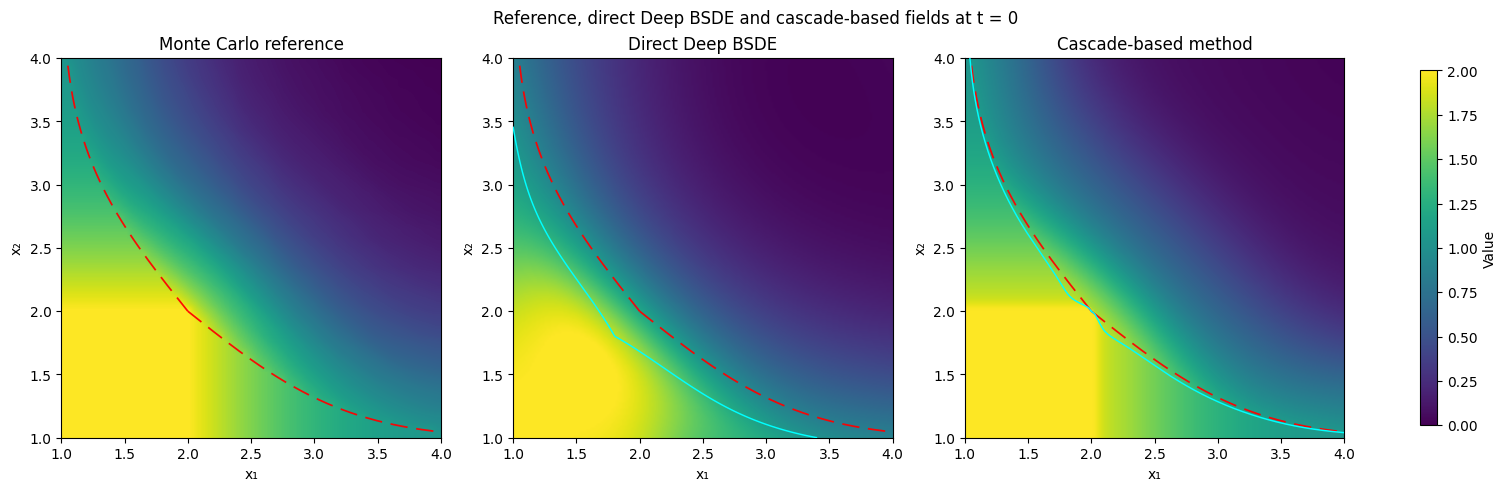

In [23]:
reference = reference_surfaces[0.0]
reference_axis = tensor_to_numpy(reference["axis"])
reference_field = tensor_to_numpy(reference["field"]).reshape(
    CASCADE.reference_grid_size,
    CASCADE.reference_grid_size,
)
cascade_axis, cascade_field = cascade_surfaces[0.0]

fig, axes = plt.subplots(
    1, 3, figsize=(15.0, 4.8), constrained_layout=True
)
image = None
panels = (
    (axes[0], reference_axis, reference_field, "Monte Carlo reference"),
    (axes[1], direct_axis, direct_field, "Direct Deep BSDE"),
    (axes[2], cascade_axis, cascade_field, "Cascade-based method"),
)
for ax, axis_np, field, title in panels:
    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]],
        aspect="equal",
        interpolation="bilinear",
        cmap="viridis",
        vmin=0.0,
        vmax=2.0,
    )
    plot_exact_boundary(ax, 0.0)
    ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
    ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(title)

if (
    np.nanmin(direct_level_set) <= 0.0
    and np.nanmax(direct_level_set) >= 0.0
):
    axes[1].contour(
        direct_axis,
        direct_axis,
        direct_level_set.T,
        levels=[0.0],
        colors=["cyan"],
        linestyles="-",
        linewidths=1.05,
        zorder=6,
    )

plot_graph_boundary(
    axes[2],
    0.0,
    learned_boundary_value,
    color="cyan",
    linestyle="-",
    linewidth=1.05,
)

if image is None:
    raise RuntimeError("No comparison heatmap was created")
fig.colorbar(image, ax=axes, shrink=0.88, label="Value")
fig.suptitle("Reference, direct Deep BSDE and cascade-based fields at t = 0")
save_figure(
    fig,
    RESULTS_DIR / "06_thesis_heatmap_comparison_t0.pdf",
)

## 7 Higher-dimensional extension

## 8 Monitoring-grid sensitivity

In [24]:
SENSITIVITY_DIR = RESULTS_DIR / "07_monitoring_sensitivity"
SENSITIVITY_DIR.mkdir(parents=True, exist_ok=True)

SENSITIVITY_POINTS = torch.tensor(
    [
        [2.50, 2.50],
        [2.05, 2.50],
        [1.80, 3.50],
        [3.00, 3.00],
        [3.50, 3.50],
    ],
    device=DEVICE,
    dtype=DTYPE,
)
SENSITIVITY_STEPS = (400, 1600, 6400)
SENSITIVITY_PATHS = 8192
SENSITIVITY_PATH_BATCH = 1024


@torch.no_grad()
def aggregate_increments(
    fine_increments: Tensor,
    coarse_steps: int,
) -> Tensor:
    fine_steps = fine_increments.shape[1]
    if fine_steps % coarse_steps != 0:
        raise ValueError("fine_steps must be divisible by coarse_steps")
    ratio = fine_steps // coarse_steps
    return fine_increments.reshape(
        fine_increments.shape[0],
        coarse_steps,
        ratio,
        fine_increments.shape[2],
    ).sum(dim=2)


@torch.no_grad()
def monitoring_grid_sensitivity(
    *,
    points: Tensor,
    steps: tuple[int, ...],
    n_paths: int,
    path_batch: int,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    fine_steps = max(steps)
    if n_paths % 2 != 0:
        raise ValueError("n_paths must be even")
    if path_batch % 2 != 0:
        raise ValueError("path_batch must be even")

    n_pairs = n_paths // 2
    sums = {
        step: torch.zeros(points.shape[0], device=DEVICE, dtype=torch.float64)
        for step in steps
    }
    sumsq = {
        step: torch.zeros(points.shape[0], device=DEVICE, dtype=torch.float64)
        for step in steps
    }
    diff_sums = {
        step: torch.zeros(points.shape[0], device=DEVICE, dtype=torch.float64)
        for step in steps
        if step != fine_steps
    }
    diff_sumsq = {
        step: torch.zeros(points.shape[0], device=DEVICE, dtype=torch.float64)
        for step in steps
        if step != fine_steps
    }

    generator = make_generator(seed)
    processed = 0
    processed_pairs = 0

    while processed < n_paths:
        current = min(path_batch, n_paths - processed)
        half = current // 2

        half_normals = torch.randn(
            half,
            fine_steps,
            2,
            generator=generator,
            device=DEVICE,
            dtype=DTYPE,
        )
        normals = torch.cat((half_normals, -half_normals), dim=0)
        dt_fine = CASCADE.terminal_time / fine_steps
        fine_increments = (
            CASCADE.sigma * math.sqrt(dt_fine) * normals
        )

        pair_values: dict[int, Tensor] = {}
        for step in steps:
            increments = (
                fine_increments
                if step == fine_steps
                else aggregate_increments(fine_increments, step)
            )
            values = reference_pathwise_value_chunk(
                start_time=0.0,
                points=points,
                increments=increments,
            ).to(torch.float64)
            pair_values[step] = 0.5 * (
                values[:, :half] + values[:, half:]
            )

        for step, pair_value in pair_values.items():
            sums[step] += pair_value.sum(dim=1)
            sumsq[step] += pair_value.square().sum(dim=1)

        fine_pair = pair_values[fine_steps]
        for step in steps:
            if step == fine_steps:
                continue
            diff = fine_pair - pair_values[step]
            diff_sums[step] += diff.sum(dim=1)
            diff_sumsq[step] += diff.square().sum(dim=1)

        processed += current
        processed_pairs += half
        print(f"Monitoring sensitivity paths {processed}/{n_paths}")

    if processed_pairs != n_pairs:
        raise RuntimeError("Unexpected antithetic pair count")

    estimate_rows = []
    difference_rows = []

    for point_index, point in enumerate(points):
        for step in steps:
            mean = sums[step][point_index] / n_pairs
            second = sumsq[step][point_index] / n_pairs
            variance = torch.clamp(second - mean.square(), min=0.0)
            se = torch.sqrt(variance / n_pairs)
            estimate_rows.append({
                "x1": float(point[0].cpu()),
                "x2": float(point[1].cpu()),
                "steps": step,
                "estimate": float(mean.cpu()),
                "standard_error": float(se.cpu()),
            })

        for step in steps:
            if step == fine_steps:
                continue
            mean = diff_sums[step][point_index] / n_pairs
            second = diff_sumsq[step][point_index] / n_pairs
            variance = torch.clamp(second - mean.square(), min=0.0)
            se = torch.sqrt(variance / n_pairs)
            difference_rows.append({
                "x1": float(point[0].cpu()),
                "x2": float(point[1].cpu()),
                "coarse_steps": step,
                "fine_steps": fine_steps,
                "fine_minus_coarse": float(mean.cpu()),
                "paired_standard_error": float(se.cpu()),
            })

    return pd.DataFrame(estimate_rows), pd.DataFrame(difference_rows)


monitoring_estimates, monitoring_differences = monitoring_grid_sensitivity(
    points=SENSITIVITY_POINTS,
    steps=SENSITIVITY_STEPS,
    n_paths=SENSITIVITY_PATHS,
    path_batch=SENSITIVITY_PATH_BATCH,
    seed=SEED + 50_000,
)

monitoring_estimates.to_csv(
    SENSITIVITY_DIR / "pointwise_monitoring_estimates.csv",
    index=False,
)
monitoring_differences.to_csv(
    SENSITIVITY_DIR / "pointwise_monitoring_differences.csv",
    index=False,
)

display(monitoring_estimates.round(6))
display(monitoring_differences.round(6))

Monitoring sensitivity paths 1024/8192
Monitoring sensitivity paths 2048/8192
Monitoring sensitivity paths 3072/8192
Monitoring sensitivity paths 4096/8192
Monitoring sensitivity paths 5120/8192
Monitoring sensitivity paths 6144/8192
Monitoring sensitivity paths 7168/8192
Monitoring sensitivity paths 8192/8192


,x1,x2,steps,estimate,standard_error
0,2.50,2.5,400,0.765093,0.005902
1,2.50,2.5,1600,0.781279,0.005792
2,2.50,2.5,6400,0.787300,0.005779
3,2.05,2.5,400,1.179976,0.006265
4,2.05,2.5,1600,1.192771,0.006299
5,2.05,2.5,6400,1.199533,0.006310
6,1.80,3.5,400,0.615214,0.004901
7,1.80,3.5,1600,0.625545,0.004882
8,1.80,3.5,6400,0.632647,0.004879
9,3.00,3.0,400,0.217179,0.005546


,x1,x2,coarse_steps,fine_steps,fine_minus_coarse,paired_standard_error
0,2.50,2.5,400,6400,0.022206,0.002317
1,2.50,2.5,1600,6400,0.006020,0.001162
2,2.05,2.5,400,6400,0.019557,0.002255
3,2.05,2.5,1600,6400,0.006762,0.001330
4,1.80,3.5,400,6400,0.017433,0.001746
5,1.80,3.5,1600,6400,0.007102,0.001134
6,3.00,3.0,400,6400,0.009218,0.001476
7,3.00,3.0,1600,6400,0.003459,0.000895
8,3.50,3.5,400,6400,0.003370,0.000843
9,3.50,3.5,1600,6400,0.000648,0.000372


In [25]:
PAIRED_REFERENCE_COARSE_STEPS = 400
PAIRED_REFERENCE_FINE_STEPS = 1600
PAIRED_REFERENCE_PATHS = 2048
PAIRED_REFERENCE_POINT_BATCH = 512


@torch.no_grad()
def paired_reference_surface(
    *,
    start_time: float,
    coarse_steps: int,
    fine_steps: int,
    n_paths: int,
    point_batch: int,
    seed: int,
) -> dict[str, Tensor]:
    if fine_steps % coarse_steps != 0:
        raise ValueError("fine_steps must be divisible by coarse_steps")
    if n_paths % 2 != 0:
        raise ValueError("n_paths must be even")

    axis = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        CASCADE.reference_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
    inside = exact_domain_mask(start_time, points)

    coarse_field = exact_singleton_value(
        start_time, points.max(dim=1).values
    )
    fine_field = coarse_field.clone()
    paired_se = torch.zeros_like(coarse_field)

    if abs(start_time - CASCADE.terminal_time) <= 1.0e-12:
        coarse_field[inside] = 0.0
        fine_field[inside] = 0.0
        return {
            "axis": axis.cpu(),
            "points": points.cpu(),
            "inside": inside.cpu(),
            "coarse_field": coarse_field.cpu(),
            "fine_field": fine_field.cpu(),
            "paired_difference_se": paired_se.cpu(),
        }

    half_paths = n_paths // 2
    generator = make_generator(seed)
    half_normals = torch.randn(
        half_paths,
        fine_steps,
        2,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    normals = torch.cat((half_normals, -half_normals), dim=0)
    dt_fine = (CASCADE.terminal_time - start_time) / fine_steps
    fine_increments = CASCADE.sigma * math.sqrt(dt_fine) * normals
    coarse_increments = aggregate_increments(
        fine_increments, coarse_steps
    )

    inside_points = points[inside]
    coarse_values = []
    fine_values = []
    paired_errors = []

    for start in range(0, inside_points.shape[0], point_batch):
        chunk = inside_points[start:start + point_batch]

        coarse_samples = reference_pathwise_value_chunk(
            start_time=start_time,
            points=chunk,
            increments=coarse_increments,
        )
        fine_samples = reference_pathwise_value_chunk(
            start_time=start_time,
            points=chunk,
            increments=fine_increments,
        )

        coarse_pair = 0.5 * (
            coarse_samples[:, :half_paths]
            + coarse_samples[:, half_paths:]
        )
        fine_pair = 0.5 * (
            fine_samples[:, :half_paths]
            + fine_samples[:, half_paths:]
        )
        difference_pair = fine_pair - coarse_pair

        coarse_values.append(coarse_pair.mean(dim=1))
        fine_values.append(fine_pair.mean(dim=1))
        paired_errors.append(
            difference_pair.std(dim=1, unbiased=True)
            / math.sqrt(half_paths)
        )

        print(
            f"Paired reference t={start_time:.2f} "
            f"{min(start + point_batch, inside_points.shape[0])}/"
            f"{inside_points.shape[0]}"
        )

    coarse_field[inside] = torch.cat(coarse_values)
    fine_field[inside] = torch.cat(fine_values)
    paired_se[inside] = torch.cat(paired_errors)

    return {
        "axis": axis.cpu(),
        "points": points.cpu(),
        "inside": inside.cpu(),
        "coarse_field": coarse_field.cpu(),
        "fine_field": fine_field.cpu(),
        "paired_difference_se": paired_se.cpu(),
    }


paired_reference_surfaces = {
    float(t_value): paired_reference_surface(
        start_time=float(t_value),
        coarse_steps=PAIRED_REFERENCE_COARSE_STEPS,
        fine_steps=PAIRED_REFERENCE_FINE_STEPS,
        n_paths=PAIRED_REFERENCE_PATHS,
        point_batch=PAIRED_REFERENCE_POINT_BATCH,
        seed=SEED + 60_000 + int(1000 * float(t_value)),
    )
    for t_value in CASCADE.comparison_times
}

paired_reference_rows = []
for t_value, result in paired_reference_surfaces.items():
    inside = result["inside"]
    difference = (
        result["fine_field"][inside]
        - result["coarse_field"][inside]
    )
    paired_reference_rows.append({
        "time": t_value,
        "coarse_steps": PAIRED_REFERENCE_COARSE_STEPS,
        "fine_steps": PAIRED_REFERENCE_FINE_STEPS,
        "mean_fine_minus_coarse": float(difference.mean()),
        "mean_absolute_change": float(difference.abs().mean()),
        "maximum_absolute_change": float(difference.abs().max()),
        "mean_paired_standard_error": float(
            result["paired_difference_se"][inside].mean()
        ),
    })

paired_reference_summary = pd.DataFrame(paired_reference_rows)
paired_reference_summary.to_csv(
    SENSITIVITY_DIR / "paired_reference_400_vs_1600.csv",
    index=False,
)
display(paired_reference_summary.round(6))

for t_value, result in paired_reference_surfaces.items():
    np.savez_compressed(
        SENSITIVITY_DIR / f"paired_reference_t{t_value:.2f}.npz",
        axis=result["axis"].numpy(),
        points=result["points"].numpy(),
        inside=result["inside"].numpy(),
        coarse_field=result["coarse_field"].numpy(),
        fine_field=result["fine_field"].numpy(),
        paired_difference_se=result["paired_difference_se"].numpy(),
    )

Paired reference t=0.00 512/2634
Paired reference t=0.00 1024/2634
Paired reference t=0.00 1536/2634
Paired reference t=0.00 2048/2634
Paired reference t=0.00 2560/2634
Paired reference t=0.00 2634/2634
Paired reference t=0.50 512/2806
Paired reference t=0.50 1024/2806
Paired reference t=0.50 1536/2806
Paired reference t=0.50 2048/2806
Paired reference t=0.50 2560/2806
Paired reference t=0.50 2806/2806
Paired reference t=0.90 512/3032
Paired reference t=0.90 1024/3032
Paired reference t=0.90 1536/3032
Paired reference t=0.90 2048/3032
Paired reference t=0.90 2560/3032
Paired reference t=0.90 3032/3032
Paired reference t=0.95 512/3086
Paired reference t=0.95 1024/3086
Paired reference t=0.95 1536/3086
Paired reference t=0.95 2048/3086
Paired reference t=0.95 2560/3086
Paired reference t=0.95 3072/3086
Paired reference t=0.95 3086/3086


,time,coarse_steps,fine_steps,mean_fine_minus_coarse,mean_absolute_change,maximum_absolute_change,mean_paired_standard_error
0,0.00,400,1600,0.009157,0.009166,0.033431,0.002568
1,0.50,400,1600,0.007001,0.007005,0.037416,0.002011
2,0.90,400,1600,0.002973,0.002977,0.040076,0.000913
3,0.95,400,1600,0.002079,0.002088,0.044511,0.000654


In [26]:
@torch.no_grad()
def field_error_against_reference(
    prediction: Tensor,
    reference: Tensor,
    inside: Tensor,
) -> tuple[float, float]:
    error = prediction[inside] - reference[inside]
    return (
        float(error.abs().mean().cpu()),
        float(torch.sqrt(error.square().mean()).cpu()),
    )


reference_sensitivity_rows = []
for t_value in CASCADE.comparison_times:
    result = paired_reference_surfaces[float(t_value)]
    points = result["points"].to(DEVICE)
    inside = result["inside"].to(DEVICE)
    reference_400 = result["coarse_field"].to(DEVICE)
    reference_1600 = result["fine_field"].to(DEVICE)

    exact_prediction = completed_exact_boundary_field(
        float(t_value), points
    )
    cascade_prediction = completed_cascade_field(
        float(t_value), points
    )

    for method, prediction in (
        ("Exact-boundary benchmark", exact_prediction),
        ("Cascade-based", cascade_prediction),
    ):
        mae_400, rmse_400 = field_error_against_reference(
            prediction, reference_400, inside
        )
        mae_1600, rmse_1600 = field_error_against_reference(
            prediction, reference_1600, inside
        )
        reference_sensitivity_rows.append({
            "method": method,
            "time": float(t_value),
            "MAE vs 400-step reference": mae_400,
            "RMSE vs 400-step reference": rmse_400,
            "MAE vs 1600-step reference": mae_1600,
            "RMSE vs 1600-step reference": rmse_1600,
        })

result = paired_reference_surfaces[0.0]
points = result["points"].to(DEVICE)
inside = result["inside"].to(DEVICE)
direct_prediction = direct_model.aggregate_value(points)
mae_400, rmse_400 = field_error_against_reference(
    direct_prediction, result["coarse_field"].to(DEVICE), inside
)
mae_1600, rmse_1600 = field_error_against_reference(
    direct_prediction, result["fine_field"].to(DEVICE), inside
)
reference_sensitivity_rows.append({
    "method": "Direct Deep BSDE",
    "time": 0.0,
    "MAE vs 400-step reference": mae_400,
    "RMSE vs 400-step reference": rmse_400,
    "MAE vs 1600-step reference": mae_1600,
    "RMSE vs 1600-step reference": rmse_1600,
})

reference_sensitivity_metrics = pd.DataFrame(reference_sensitivity_rows)
reference_sensitivity_metrics.to_csv(
    SENSITIVITY_DIR / "model_errors_400_vs_1600_reference.csv",
    index=False,
)
display(reference_sensitivity_metrics.round(6))

,method,time,MAE vs 400-step reference,RMSE vs 400-step reference,MAE vs 1600-step reference,RMSE vs 1600-step reference
0,Exact-boundary benchmark,0.00,0.027429,0.032794,0.032241,0.038632
1,Cascade-based,0.00,0.068925,0.077392,0.077735,0.087129
2,Exact-boundary benchmark,0.50,0.018324,0.030032,0.022499,0.035045
3,Cascade-based,0.50,0.034313,0.050067,0.040347,0.057861
4,Exact-boundary benchmark,0.90,0.051299,0.100446,0.050539,0.098182
5,Cascade-based,0.90,0.047241,0.093263,0.046095,0.091118
6,Exact-boundary benchmark,0.95,0.080406,0.168175,0.079625,0.166299
7,Cascade-based,0.95,0.082232,0.153607,0.081739,0.152525
8,Direct Deep BSDE,0.00,0.256007,0.308476,0.265153,0.318882


## 9 Three-seed robustness

In [27]:
MULTISEED_DIR = RESULTS_DIR / "08_multiseed"
MULTISEED_DIR.mkdir(parents=True, exist_ok=True)

BASE_SEEDS = (123, 456, 789)

robust_direct_validation_batch = sample_brownian_batch(
    batch_size=CASCADE.validation_size,
    dimension=2,
    steps=CASCADE.train_steps,
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    max_start_time=0.0,
    sigma=CASCADE.sigma,
    generator=make_generator(91_000),
    antithetic=False,
)

robust_n2_validation_data = sample_n2_training_data(
    batch_size=CASCADE.validation_size,
    generator=make_generator(92_000),
    antithetic=False,
)

robust_singleton_validation_data = sample_singleton_training_data(
    batch_size=CASCADE.validation_size,
    generator=make_generator(93_000),
    antithetic=False,
)

robust_diagnostic_batch = sample_brownian_batch(
    batch_size=CASCADE.diagnostic_paths,
    dimension=2,
    steps=CASCADE.diagnostic_steps,
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    max_start_time=0.0,
    sigma=CASCADE.sigma,
    generator=make_generator(94_000),
    antithetic=False,
)


def make_local_singleton_providers(
    model: BoundedSingletonFBSDE,
) -> tuple[Callable, Callable]:
    @torch.no_grad()
    def value_provider(
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        t_tensor = torch.as_tensor(
            t, device=x.device, dtype=x.dtype
        )
        t_tensor, x_tensor = torch.broadcast_tensors(
            t_tensor, x
        )
        raw = model.value(
            t_tensor.reshape(-1),
            x_tensor.reshape(-1),
        ).reshape(x_tensor.shape)
        return torch.where(
            x_tensor <= 2.0 * CASCADE.alpha,
            torch.full_like(raw, 2.0),
            raw,
        )

    def boundary_provider(
        t: float | Tensor,
        r: Tensor,
    ) -> Tensor:
        return CASCADE.alpha * value_provider(t, r)

    return value_provider, boundary_provider


def fit_exact_boundary_seed(
    base_seed: int,
) -> tuple[SymmetricTwoParticleFBSDE, TrainingResult]:
    model_seed = base_seed + 200
    output_dir = MULTISEED_DIR / f"seed_{base_seed}" / "exact_boundary"
    seed_everything(model_seed)

    model = SymmetricTwoParticleFBSDE(
        x_min=CASCADE.x_min,
        x_max=CASCADE.x_max,
        width=CASCADE.width,
        depth=CASCADE.depth,
    ).to(DEVICE)

    train_generator = make_generator(model_seed + 1)

    def train_objective(current_model: nn.Module) -> Tensor:
        data = sample_n2_training_data(
            batch_size=OPTIM.batch_size,
            generator=train_generator,
            antithetic=True,
        )
        total, _ = n2_loss(
            model=current_model,
            batch=data[0],
            boundary_provider=exact_boundary_provider,
            boundary_value_provider=exact_boundary_value_provider,
            terminal_value=0.0,
            boundary_sample_time=data[1],
            remaining_coordinate=data[2],
            terminal_points=data[3],
            terminal_mask_function=exact_terminal_domain_mask,
        )
        return total

    def validation_objective(current_model: nn.Module) -> Tensor:
        total, _ = n2_loss(
            model=current_model,
            batch=robust_n2_validation_data[0],
            boundary_provider=exact_boundary_provider,
            boundary_value_provider=exact_boundary_value_provider,
            terminal_value=0.0,
            boundary_sample_time=robust_n2_validation_data[1],
            remaining_coordinate=robust_n2_validation_data[2],
            terminal_points=robust_n2_validation_data[3],
            terminal_mask_function=exact_terminal_domain_mask,
        )
        return total

    result = train(
        model=model,
        name="exact_boundary",
        output_dir=output_dir,
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=OPTIM.iterations,
        learning_rate=OPTIM.learning_rate,
        validation_every=OPTIM.validation_every,
        display_every=OPTIM.display_every,
        scheduler_step=OPTIM.scheduler_step,
        scheduler_gamma=OPTIM.scheduler_gamma,
        gradient_clip=OPTIM.gradient_clip,
    )
    model.eval()
    torch.save(model.state_dict(), output_dir / "model.pt")
    return model, result


def fit_direct_seed(
    base_seed: int,
) -> tuple[DirectGlobalFBSDE, TrainingResult]:
    output_dir = MULTISEED_DIR / f"seed_{base_seed}" / "direct"
    seed_everything(base_seed)
    model = DirectGlobalFBSDE(
        x_min=CASCADE.x_min,
        x_max=CASCADE.x_max,
        width=CASCADE.width,
        depth=CASCADE.depth,
    ).to(DEVICE)
    result = train_direct_model(
        model=model,
        seed=base_seed,
        output_dir=output_dir,
        validation_batch=robust_direct_validation_batch,
    )
    model.eval()
    torch.save(model.state_dict(), output_dir / "model.pt")
    return model, result


def fit_singleton_seed(
    base_seed: int,
) -> tuple[BoundedSingletonFBSDE, TrainingResult]:
    model_seed = base_seed + 500
    output_dir = MULTISEED_DIR / f"seed_{base_seed}" / "singleton"
    seed_everything(model_seed)

    model = BoundedSingletonFBSDE(
        x_min=2.0 * CASCADE.alpha,
        x_max=CASCADE.x_max,
        width=CASCADE.width,
        depth=CASCADE.depth,
    ).to(DEVICE)

    train_generator = make_generator(model_seed + 1)

    def train_objective(current_model: nn.Module) -> Tensor:
        data = sample_singleton_training_data(
            batch_size=OPTIM.batch_size,
            generator=train_generator,
            antithetic=True,
        )
        total, _ = singleton_loss(
            model=current_model,
            batch=data[0],
            boundary_time=data[1],
            terminal_x=data[2],
            monotone_time=data[3],
            monotone_x=data[4],
        )
        return total

    def validation_objective(current_model: nn.Module) -> Tensor:
        with torch.enable_grad():
            total, _ = singleton_loss(
                model=current_model,
                batch=robust_singleton_validation_data[0],
                boundary_time=robust_singleton_validation_data[1],
                terminal_x=robust_singleton_validation_data[2],
                monotone_time=robust_singleton_validation_data[3],
                monotone_x=robust_singleton_validation_data[4],
            )
        return total

    result = train(
        model=model,
        name="singleton",
        output_dir=output_dir,
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=OPTIM.iterations,
        learning_rate=OPTIM.learning_rate,
        validation_every=OPTIM.validation_every,
        display_every=OPTIM.display_every,
        scheduler_step=OPTIM.scheduler_step,
        scheduler_gamma=OPTIM.scheduler_gamma,
        gradient_clip=OPTIM.gradient_clip,
    )
    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)
    torch.save(model.state_dict(), output_dir / "model.pt")
    return model, result


def fit_cascade_seed(
    base_seed: int,
    singleton_model_local: BoundedSingletonFBSDE,
) -> tuple[SymmetricTwoParticleFBSDE, TrainingResult]:
    model_seed = base_seed + 600
    output_dir = MULTISEED_DIR / f"seed_{base_seed}" / "cascade"
    seed_everything(model_seed)

    singleton_value_provider, boundary_provider = (
        make_local_singleton_providers(singleton_model_local)
    )

    model = SymmetricTwoParticleFBSDE(
        x_min=CASCADE.x_min,
        x_max=CASCADE.x_max,
        width=CASCADE.width,
        depth=CASCADE.depth,
    ).to(DEVICE)

    train_generator = make_generator(model_seed + 1)

    def terminal_domain_mask(points: Tensor) -> Tensor:
        smaller = points.min(dim=1).values
        larger = points.max(dim=1).values
        threshold = boundary_provider(
            torch.ones_like(larger), larger
        )
        return smaller > threshold

    def train_objective(current_model: nn.Module) -> Tensor:
        data = sample_n2_training_data(
            batch_size=OPTIM.batch_size,
            generator=train_generator,
            antithetic=True,
        )
        total, _ = n2_loss(
            model=current_model,
            batch=data[0],
            boundary_provider=boundary_provider,
            boundary_value_provider=singleton_value_provider,
            terminal_value=0.0,
            boundary_sample_time=data[1],
            remaining_coordinate=data[2],
            terminal_points=data[3],
            terminal_mask_function=terminal_domain_mask,
        )
        return total

    def validation_objective(current_model: nn.Module) -> Tensor:
        total, _ = n2_loss(
            model=current_model,
            batch=robust_n2_validation_data[0],
            boundary_provider=boundary_provider,
            boundary_value_provider=singleton_value_provider,
            terminal_value=0.0,
            boundary_sample_time=robust_n2_validation_data[1],
            remaining_coordinate=robust_n2_validation_data[2],
            terminal_points=robust_n2_validation_data[3],
            terminal_mask_function=terminal_domain_mask,
        )
        return total

    result = train(
        model=model,
        name="cascade",
        output_dir=output_dir,
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=OPTIM.iterations,
        learning_rate=OPTIM.learning_rate,
        validation_every=OPTIM.validation_every,
        display_every=OPTIM.display_every,
        scheduler_step=OPTIM.scheduler_step,
        scheduler_gamma=OPTIM.scheduler_gamma,
        gradient_clip=OPTIM.gradient_clip,
    )
    model.eval()
    torch.save(model.state_dict(), output_dir / "model.pt")
    return model, result

In [28]:
@torch.no_grad()
def local_completed_value(
    model: SymmetricTwoParticleFBSDE,
    t_value: float,
    points: Tensor,
    boundary_provider: Callable,
    boundary_value_provider: Callable,
) -> Tensor:
    return completed_n2_value(
        model=model,
        t=t_value,
        points=points,
        boundary_provider=boundary_provider,
        boundary_value_provider=boundary_value_provider,
        terminal_value=0.0,
    )


@torch.no_grad()
def local_exit_metrics(
    *,
    direct_model_local: DirectGlobalFBSDE,
    cascade_boundary_provider: Callable,
) -> tuple[dict[str, float], dict[str, float]]:
    exact_index_local, exact_hit_local = prescribed_exit_indices(
        robust_diagnostic_batch, exact_boundary_provider
    )
    cascade_index_local, cascade_hit_local = prescribed_exit_indices(
        robust_diagnostic_batch, cascade_boundary_provider
    )
    direct_rollout = direct_global_rollout(
        direct_model_local, robust_diagnostic_batch
    )

    dt_local = CASCADE.terminal_time / CASCADE.diagnostic_steps

    def row(index: Tensor, hit: Tensor) -> dict[str, float]:
        both_hit = exact_hit_local & hit
        return {
            "Exit occurrence agreement": float(
                (exact_hit_local == hit).to(DTYPE).mean().cpu()
            ),
            "Censored exit-time MAE": float(
                (exact_index_local.to(DTYPE) - index.to(DTYPE))
                .abs().mean().cpu() * dt_local
            ),
            "Both-hit exit-time RMSE": (
                float(
                    torch.sqrt(
                        (
                            exact_index_local[both_hit].to(DTYPE)
                            - index[both_hit].to(DTYPE)
                        ).square().mean()
                    ).cpu() * dt_local
                )
                if bool(both_hit.any())
                else math.nan
            ),
        }

    return (
        row(
            direct_rollout["first_exit_index"],
            direct_rollout["first_exit_hit"],
        ),
        row(cascade_index_local, cascade_hit_local),
    )


def evaluate_multiseed_run(
    *,
    base_seed: int,
    exact_model_local: SymmetricTwoParticleFBSDE,
    exact_result: TrainingResult,
    direct_model_local: DirectGlobalFBSDE,
    direct_result: TrainingResult,
    singleton_model_local: BoundedSingletonFBSDE,
    singleton_result: TrainingResult,
    cascade_model_local: SymmetricTwoParticleFBSDE,
    cascade_result: TrainingResult,
) -> list[dict[str, float | int | str]]:
    ref = paired_reference_surfaces[0.0]
    points = ref["points"].to(DEVICE)
    inside = ref["inside"].to(DEVICE)
    ref400 = ref["coarse_field"].to(DEVICE)
    ref1600 = ref["fine_field"].to(DEVICE)

    local_singleton_value, local_boundary = (
        make_local_singleton_providers(singleton_model_local)
    )

    exact_prediction = local_completed_value(
        exact_model_local,
        0.0,
        points,
        exact_boundary_provider,
        exact_boundary_value_provider,
    )
    direct_prediction = direct_model_local.aggregate_value(points)
    cascade_prediction = local_completed_value(
        cascade_model_local,
        0.0,
        points,
        local_boundary,
        local_singleton_value,
    )

    direct_inside = (
        points.min(dim=1).values
        > CASCADE.alpha * direct_prediction
    )
    cascade_inside = (
        points.min(dim=1).values
        > local_boundary(0.0, points.max(dim=1).values)
    )

    direct_axis_local, _, direct_level_set_local = direct_surface(
        direct_model_local
    )
    direct_cloud = implicit_boundary_point_cloud(
        direct_axis_local, direct_level_set_local
    )
    exact_cloud = exact_boundary_point_cloud(0.0)
    direct_boundary_metrics = point_cloud_metrics(
        direct_cloud, exact_cloud
    )
    cascade_cloud = graph_boundary_point_cloud(
        0.0, local_boundary
    )
    cascade_boundary_metrics = point_cloud_metrics(
        cascade_cloud, exact_cloud
    )

    direct_exit, cascade_exit = local_exit_metrics(
        direct_model_local=direct_model_local,
        cascade_boundary_provider=local_boundary,
    )

    diagnostic_r = torch.linspace(
        2.001,
        CASCADE.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    singleton_error = (
        local_boundary(0.0, diagnostic_r)
        - exact_boundary_value(0.0, diagnostic_r)
    )

    def metrics(
        prediction: Tensor,
        predicted_inside: Tensor | None,
    ) -> dict[str, float]:
        mae400, rmse400 = field_error_against_reference(
            prediction, ref400, inside
        )
        mae1600, rmse1600 = field_error_against_reference(
            prediction, ref1600, inside
        )
        return {
            "Field MAE ref400": mae400,
            "Field RMSE ref400": rmse400,
            "Field MAE ref1600": mae1600,
            "Field RMSE ref1600": rmse1600,
            "Domain accuracy": (
                math.nan
                if predicted_inside is None
                else float(
                    (predicted_inside == inside)
                    .to(DTYPE).mean().cpu()
                )
            ),
        }

    rows = []

    rows.append({
        "base_seed": base_seed,
        "method": "Exact-boundary benchmark",
        "model_seed": base_seed + 200,
        "best_iteration": exact_result.best_iteration,
        "best_validation_loss": exact_result.best_validation_loss,
        "runtime_minutes": exact_result.runtime_seconds / 60.0,
        **metrics(exact_prediction, None),
    })

    rows.append({
        "base_seed": base_seed,
        "method": "Direct Deep BSDE",
        "model_seed": base_seed,
        "best_iteration": direct_result.best_iteration,
        "best_validation_loss": direct_result.best_validation_loss,
        "runtime_minutes": direct_result.runtime_seconds / 60.0,
        **metrics(direct_prediction, direct_inside),
        **direct_boundary_metrics,
        **direct_exit,
    })

    rows.append({
        "base_seed": base_seed,
        "method": "Cascade-based",
        "model_seed": base_seed + 600,
        "singleton_seed": base_seed + 500,
        "best_iteration": cascade_result.best_iteration,
        "best_validation_loss": cascade_result.best_validation_loss,
        "singleton_best_iteration": singleton_result.best_iteration,
        "singleton_validation_loss": singleton_result.best_validation_loss,
        "runtime_minutes": (
            singleton_result.runtime_seconds
            + cascade_result.runtime_seconds
        ) / 60.0,
        "Singleton threshold MAE t0": float(
            singleton_error.abs().mean().cpu()
        ),
        **metrics(cascade_prediction, cascade_inside),
        **cascade_boundary_metrics,
        **cascade_exit,
    })

    return rows

In [29]:
multiseed_rows: list[dict[str, float | int | str]] = []

for base_seed in BASE_SEEDS:
    print("=" * 80)
    print("Base seed", base_seed)

    exact_model_seed, exact_result_seed = fit_exact_boundary_seed(
        base_seed
    )
    direct_model_seed, direct_result_seed = fit_direct_seed(
        base_seed
    )
    singleton_model_seed, singleton_result_seed = fit_singleton_seed(
        base_seed
    )
    cascade_model_seed, cascade_result_seed = fit_cascade_seed(
        base_seed,
        singleton_model_seed,
    )

    multiseed_rows.extend(
        evaluate_multiseed_run(
            base_seed=base_seed,
            exact_model_local=exact_model_seed,
            exact_result=exact_result_seed,
            direct_model_local=direct_model_seed,
            direct_result=direct_result_seed,
            singleton_model_local=singleton_model_seed,
            singleton_result=singleton_result_seed,
            cascade_model_local=cascade_model_seed,
            cascade_result=cascade_result_seed,
        )
    )

    pd.DataFrame(multiseed_rows).to_csv(
        MULTISEED_DIR / "multiseed_runs_partial.csv",
        index=False,
    )

    del (
        exact_model_seed,
        direct_model_seed,
        singleton_model_seed,
        cascade_model_seed,
    )
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

multiseed_runs = pd.DataFrame(multiseed_rows)
multiseed_runs.to_csv(
    MULTISEED_DIR / "multiseed_runs.csv",
    index=False,
)

numeric_columns = [
    column
    for column in multiseed_runs.columns
    if column not in {
        "base_seed",
        "method",
        "model_seed",
        "singleton_seed",
    }
    and pd.api.types.is_numeric_dtype(multiseed_runs[column])
]

multiseed_summary = (
    multiseed_runs
    .groupby("method")[numeric_columns]
    .agg(["mean", "std", "min", "max"])
)
multiseed_summary.to_csv(
    MULTISEED_DIR / "multiseed_summary.csv"
)

display(multiseed_runs.round(6))
display(multiseed_summary.round(6))

Base seed 123
exact_boundary                     iteration   200 train 4.809514e-01 val 4.922223e-01
exact_boundary                     iteration   400 train 4.680241e-01 val 4.444747e-01
exact_boundary                     iteration   600 train 3.649977e-01 val 3.920454e-01
exact_boundary                     iteration   800 train 2.812978e-01 val 2.763983e-01
exact_boundary                     iteration  1000 train 2.651366e-01 val 2.811926e-01
exact_boundary                     iteration  1200 train 2.452375e-01 val 2.393618e-01
exact_boundary                     iteration  1400 train 2.258342e-01 val 2.285187e-01
exact_boundary                     iteration  1600 train 2.110668e-01 val 2.034629e-01
exact_boundary                     iteration  1800 train 1.552745e-01 val 1.821408e-01
exact_boundary                     iteration  2000 train 1.541496e-01 val 1.547714e-01
exact_boundary                     iteration  2200 train 1.445000e-01 val 1.384602e-01
exact_boundary               

,base_seed,method,model_seed,best_iteration,best_validation_loss,runtime_minutes,Field MAE ref400,Field RMSE ref400,Field MAE ref1600,Field RMSE ref1600,...,Mean boundary distance,Boundary RMSE,Discrete point-cloud Hausdorff distance,Exit occurrence agreement,Censored exit-time MAE,Both-hit exit-time RMSE,singleton_seed,singleton_best_iteration,singleton_validation_loss,Singleton threshold MAE t0
0,123,Exact-boundary benchmark,323,14800,0.020519,21.254791,0.027429,0.032794,0.032241,0.038632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,123,Direct Deep BSDE,123,15000,0.005864,15.248262,0.256007,0.308476,0.265153,0.318882,...,0.236925,0.251393,0.593414,0.88420,0.101805,0.143566,NaN,NaN,NaN,NaN
2,123,Cascade-based,723,15000,0.024547,34.589283,0.070433,0.078834,0.079209,0.088634,...,0.029189,0.034110,0.068758,0.99120,0.011223,0.048470,623.0,14600.0,0.008310,0.034545
3,456,Exact-boundary benchmark,656,14800,0.024312,21.306292,0.031453,0.036997,0.035791,0.041696,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,456,Direct Deep BSDE,456,15000,0.006020,15.205399,0.266745,0.317938,0.275902,0.328358,...,0.257075,0.278313,0.693162,0.88220,0.104078,0.147111,NaN,NaN,NaN,NaN
5,456,Cascade-based,1056,14600,0.023687,34.511445,0.043274,0.052384,0.052107,0.062373,...,0.031468,0.034586,0.061169,0.99140,0.011440,0.049615,956.0,14200.0,0.008400,0.036766
6,789,Exact-boundary benchmark,989,14800,0.023129,21.314159,0.035531,0.042529,0.041004,0.048119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,789,Direct Deep BSDE,789,15000,0.006019,15.176729,0.262864,0.315069,0.272020,0.325478,...,0.271315,0.293863,0.709793,0.88585,0.101882,0.146903,NaN,NaN,NaN,NaN
8,789,Cascade-based,1389,14400,0.026786,34.597050,0.045987,0.053582,0.054845,0.063096,...,0.029167,0.033547,0.068359,0.99265,0.010555,0.049746,1289.0,14400.0,0.008579,0.034422


best_iteration                            \
                                   mean         std    min    max   
method                                                              
Cascade-based              14666.666667  305.505046  14400  15000   
Direct Deep BSDE           15000.000000    0.000000  15000  15000   
Exact-boundary benchmark   14800.000000    0.000000  14800  14800   

                         best_validation_loss                                \
                                         mean       std       min       max   
method                                                                        
Cascade-based                        0.025006  0.001600  0.023687  0.026786   
Direct Deep BSDE                     0.005968  0.000090  0.005864  0.006020   
Exact-boundary benchmark             0.022653  0.001941  0.020519  0.024312   

                         runtime_minutes            ...  \
                                    mean       std  ...   
method                                              ...   
Cascade-based                  34.565926  0.047342  ...   
Direct Deep BSDE               15.210130  0.036000  ...   
Exact-boundary benchmark       21.291748  0.032246  ...   

                         singleton_best_iteration           \
                                              min      max   
method                                                       
Cascade-based                             14200.0  14600.0   
Direct Deep BSDE                              NaN      NaN   
Exact-boundary benchmark                      NaN      NaN   

                         singleton_validation_loss                     \
                                              mean       std      min   
method                                                                  
Cascade-based                              0.00843  0.000137  0.00831   
Direct Deep BSDE                               NaN       NaN      NaN   
Exact-boundary benchmark                       NaN       NaN      NaN   

                                   Singleton threshold MAE t0            \
                               max                       mean       std   
method                                                                    
Cascade-based             0.008579                   0.035244  0.001319   
Direct Deep BSDE               NaN                        NaN       NaN   
Exact-boundary benchmark       NaN                        NaN       NaN   

                                              
                               min       max  
method                                        
Cascade-based             0.034422  0.036766  
Direct Deep BSDE               NaN       NaN  
Exact-boundary benchmark       NaN       NaN  

[3 rows x 68 columns]

## 10 Final summary

In [30]:
final_summary = {
    "monitoring_pointwise": monitoring_differences,
    "reference_400_vs_1600": paired_reference_summary,
    "single_run_reference_sensitivity": reference_sensitivity_metrics,
    "multiseed_runs": multiseed_runs,
}
print("Saved to", RESULTS_DIR.resolve())

Saved to /content/dissertation_moving_boundary_final_results
